In [349]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
#import nipes_data_fcts as nidf
import me_data_fcts as medf
#from statannotations.Annotator import Annotator
import umap
from sklearn.preprocessing import StandardScaler


In [350]:
# if you modify me_data_fcts.py and want to reload without restarting the kernel
import importlib
importlib.reload(medf)

<module 'me_data_fcts' from '/home/leni/git/AREFramework/experiments/scripts/me_data_fcts.py'>

# Load Data

In [556]:
def load_map_elites(folder,filename):
    map_ids = medf.load_parent_pool(folder + filename)

    # print(len(map_ids))
    ids, parents, fitnesses, evals, deltas, replicate_index = medf.load_fitness(folder + "/fitness.csv")
    
    if(len(map_ids) == 1 or len(ids) < 11000):
        map_ids = map_ids[-1]
    else:
        j = 10000
        ascending = True
        found = False
        i = 0
        while not found:
            print(j)
            if j > len(ids):
                j = 9999
                ascending = False 
            for i, mids in enumerate(map_ids):
                if ids[j] in mids:
                    found = True
                    break
            if(ascending):
                j += 1
            else:
                j -= 1  
        map_ids = map_ids[i]
        
    print(len(map_ids), " robots in map")
    fit_data = []
    for id_,fit in zip(ids, fitnesses):
        if id_ in map_ids:
            fit_data.append([id_,fit])
    descriptors = medf.load_feature_descriptor(folder + "/morph_features.csv")
    descs = [[int(d[0])] + d[1:5] + [d[5]*16,
                                         d[6]*16,
                                         d[7]*16,
                                         d[8]*16]
                                           + d[9:]  + [folder] 
            for d in descriptors if int(d[0]) in map_ids]
    fit_df = pd.DataFrame(fit_data, columns = ['robot index', 'fitness'])
    desc_df = pd.DataFrame(descs, columns = [   'robot index', "width",
                                                            "depth",
                                                            "height",
                                                            "voxels",
                                                            "wheels",
                                                            "sensors",
                                                            "limbs",
                                                            "casters",
                                                            "norm",
                                                            "skeleton norm",
                                                            "components norm",
                                                            "replicate_index", 
                                                            "replicate"])
    fit_desc_df = pd.merge(fit_df, desc_df, how="left", on=["robot index"])
    return fit_desc_df

def load_map_elites_env(name,folders,filename):
    robot_data = []
    for folder in folders:
        print(folder)
        data = load_map_elites(folder,filename)
        data['environment'] = name
        robot_data.append(data)
    return pd.concat(robot_data).reset_index(drop=True)

In [557]:
def load_experiment(name, folders):
    experiments_loaded = 0
    exp_fits = []
    for folder in folders:
        #print(folder)
        ids, parents, fitnesses, evals, deltas, replicate_index = medf.load_fitness(folder + "/fitness.csv")
        eval_times = medf.load_comp_time_dict(folder + "/times.csv")
        fits = [[i, p[0], p[1], eval_times[i][0]/(1000000*3600), eval_times[i][1]/(1000000*3600), f, folder, r] 
                for i, p, f, r in zip(ids,parents,fitnesses, replicate_index)]
        fits = fits[:10000]
        exp_fits += fits
        experiments_loaded += 1
        print(folder, " -- Robots: ", len(fits))
    fit_data = pd.DataFrame(data=exp_fits,columns=[      "robot index",
                                                         "parent 1",
                                                         "parent 2",
                                                         "evaluation time",
                                                         "time",
                                                         "fitness",
                                                         "replicate", 
                                                         "replicate_index"])
    fit_data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(fit_data))
    return fit_data

In [558]:
def load_morphology(name, folders):
    exp_descs = []
    experiments_loaded = 0
    for folder in folders:
        #parent_ids = medf.load_parent_pool(folder + "/parent_pool.csv")
        descriptors = medf.load_feature_descriptor(folder + "/morph_features.csv")
        #print(descriptors[-1])
        descs = [[int(d[0])] + d[1:5] + [d[5]*16,
                                         d[6]*16,
                                         d[7]*16,
                                         d[8]*16]
                                           + d[9:]  + [folder] 
                 for d in descriptors]
        #print(descs[-1])
        #parent_descs += medf.filter_to_parent_pool(descs,parent_ids)
        descs = descs[:10000]
        exp_descs += descs        
        print(folder, " -- Robots: ", len(descs))
        experiments_loaded += 1
    data = pd.DataFrame(data=exp_descs,columns=[
                                                            "robot index",
                                                            "width",
                                                            "depth",
                                                            "height",
                                                            "voxels",
                                                            "wheels",
                                                            "sensors",
                                                            "limbs",
                                                            "casters",
                                                            "norm",
                                                            "skeleton norm",
                                                            "components norm",
                                                            "replicate_index", 
                                                            "replicate"])
    data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(data))
    return data

## SQ_CPPN

In [559]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['meim_sq_flat', 'meim_sq_cracks'],#, 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks']#, 'Obstacles', 'Rough', 'Holyrood'],
}

In [561]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        folders.append(repo_folder + exps + '/' + folder)
    data = load_experiment(experiments['name'][idx], folders)
    data['encoding'] = 'SQ_CPPN'
    robot_data.append(data)


meim_sq_flat
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_19-16-10-816-2370462392  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_12_3_1-34-14-4030-2971763921  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_12_3_1-54-59-9138-4171306948 

In [562]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        folders.append(repo_folder + exps + '/' + folder)
    data = load_morphology(experiments['name'][idx], folders)
    data['encoding'] = 'SQ_CPPN'

    robot_desc_data.append(data)

meim_sq_flat
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_19-16-10-816-2370462392  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_12_3_1-34-14-4030-2971763921  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_12_3_1-54-59-9138-4171306948 

In [563]:
# Concat all the parents data
fit_data_sq = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data_sq = []
for env in experiments["name"]:
    tmp_data = fit_data_sq.loc[fit_data_sq["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data_sq.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data_sq[-1]["replicate"] = rep
        fit_max_data_sq[-1]["environment"] = env
        fit_max_data_sq[-1]["encoding"] = "SQ_CPPN"

fit_max_data_sq = pd.concat(fit_max_data_sq)
fit_max_data_sq.index = [i for i in range(len(fit_max_data_sq))]

In [564]:
desc_data_sq = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data_sq = pd.merge(desc_data_sq, fit_data_sq, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index","encoding"])
desc_data_sq = desc_data_sq.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


In [565]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        print(folder)
        folders.append(repo_folder + exps + '/' + folder)
    data = load_map_elites_env(experiments['name'][idx], folders,"/grid_archive.csv")
    data['encoding'] = 'SQ_CPPN'
    robot_data.append(data)
me_data_sq = pd.concat(robot_data).reset_index(drop=True)

meim_sq_flat
meim_11_3_17-59-56-6384-2102594713
meim_11_3_17-59-57-7269-4229270083
meim_11_3_17-59-57-7377-2053156979
meim_11_3_17-59-57-7467-1188062065
meim_11_3_17-59-57-7862-293875990
meim_11_3_17-59-58-8527-4068923784
meim_11_3_17-59-59-9003-1516430376
meim_11_3_19-16-10-816-2370462392
meim_12_3_1-34-14-4030-2971763921
meim_12_3_1-54-59-9138-4171306948
meim_17_3_21-46-10-81-1656396536
meim_17_3_21-46-6-6756-609832076
meim_17_3_21-46-6-6783-3024915362
meim_17_3_21-46-6-6961-3453695707
meim_17_3_21-46-7-7298-717215794
meim_17_3_21-46-8-8465-1041691031
meim_17_3_21-46-8-8472-1119555096
meim_17_3_21-46-8-8702-124492986
meim_18_3_6-1-36-6253-4195160045
meim_18_3_6-31-31-1271-1925515686
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-56-6384-2102594713
1629  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7269-4229270083
1472  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_sq_flat/meim_11_3_17-59-57-7377-2053156979
1873  robots in map


## Dual CPPNs

In [566]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['meim_cppn_flat', 'meim_cppn_cracks'],#, 'meim_cppn_obstacles', 'meim_cppn_rough', 'meim_cppn_holyrood' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks'],# 'Obstacles', 'Rough', 'Holyrood'],
}

In [567]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_experiment(experiments['name'][idx], folders)
    data['encoding'] = 'DUAL_CPPN'
    robot_data.append(data)


meim_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_13-27-13-3416-713908846  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_10_9_11-22-53-3739-2609065298  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_11_11_4-11-22-2098-3171330915  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-49-18-8162-3642162703  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-15-50-221-1269457654  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-4-45-5172-3415429603  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_19-42-36-6416-4129046457  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_9-32-1-1449-235937378  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_19_0_13-53-15-5387-189170

In [568]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []

    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_morphology(experiments['name'][idx], folders)
    data['encoding'] = 'DUAL_CPPN'

    robot_desc_data.append(data)

meim_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_13-27-13-3416-713908846  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_10_9_11-22-53-3739-2609065298  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_11_11_4-11-22-2098-3171330915  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-49-18-8162-3642162703  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-15-50-221-1269457654  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-4-45-5172-3415429603  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_19-42-36-6416-4129046457  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_9-32-1-1449-235937378  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_19_0_13-53-15-5387-189170

In [570]:
# Concat all the parents data
fit_data_cppn = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data_cppn = []
for env in experiments["name"]:
    tmp_data = fit_data_cppn.loc[fit_data_cppn["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data_cppn.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data_cppn[-1]["replicate"] = rep
        fit_max_data_cppn[-1]["environment"] = env
        fit_max_data_cppn[-1]["encoding"] = "DUAL_CPPN"

fit_max_data_cppn = pd.concat(fit_max_data_cppn)
fit_max_data_cppn.index = [i for i in range(len(fit_max_data_cppn))]

In [571]:
desc_data_cppn = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data_cppn = pd.merge(desc_data_cppn, fit_data_cppn, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index","encoding"])
desc_data_cppn = desc_data_cppn.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


In [572]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_map_elites_env(experiments['name'][idx], folders,"/grid_archive.csv")
    data['encoding'] = 'DUAL_CPPN'
    robot_data.append(data)
me_data_cppn = pd.concat(robot_data).reset_index(drop=True)
print(me_data_cppn)

meim_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_13-27-13-3416-713908846
479  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_10_9_11-22-53-3739-2609065298
348  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_11_11_4-11-22-2098-3171330915
414  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-49-18-8162-3642162703
398  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-15-50-221-1269457654
387  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-4-45-5172-3415429603
523  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_19-42-36-6416-4129046457
573  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_18_0_9-32-1-1449-235937378
728  robots in map
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_19_0_13-53-15-5387-189170

## ME SQ CPPN

In [573]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['me2im_sq_flat', 'me2im_sq_cracks'],#, 'me2im_sq_obstacles', 'me2im_sq_rough', 'me2im_sq_holyrood' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks']#, 'Obstacles', 'Rough', 'Holyrood'],
}

In [574]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_experiment(experiments['name'][idx], folders)
    data['encoding'] = 'ME_SQ_CPPN'
    robot_data.append(data)


me2im_sq_flat
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_10_0_10-48-46-6331-806446449  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_10_0_23-6-19-9667-3884520190  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_11_0_10-0-20-669-3872715664  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_11_0_6-47-2-2136-591757309  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-54-39-9478-633633757  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-55-24-4436-2635421350  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-55-28-8377-512410540  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_15_0_1-14-1-1422-836634426  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_15_0_3-1-52-2961-186232052  -- Robots:  10000
/m

In [575]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_morphology(experiments['name'][idx], folders)
    data['encoding'] = 'ME_SQ_CPPN'

    robot_desc_data.append(data)

me2im_sq_flat
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_10_0_10-48-46-6331-806446449  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_10_0_23-6-19-9667-3884520190  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_11_0_10-0-20-669-3872715664  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_11_0_6-47-2-2136-591757309  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-54-39-9478-633633757  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-55-24-4436-2635421350  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-55-28-8377-512410540  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_15_0_1-14-1-1422-836634426  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_15_0_3-1-52-2961-186232052  -- Robots:  10000
/m

In [576]:
# Concat all the parents data
fit_data_sq_me = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data_sq_me = []
for env in experiments["name"]:
    tmp_data = fit_data_sq_me.loc[fit_data_sq_me["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data_sq_me.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data_sq_me[-1]["replicate"] = rep
        fit_max_data_sq_me[-1]["environment"] = env
        fit_max_data_sq_me[-1]["encoding"] = "ME_SQ_CPPN"

fit_max_data_sq_me = pd.concat(fit_max_data_sq_me)
fit_max_data_sq_me.index = [i for i in range(len(fit_max_data_sq_me))]

In [577]:
print(fit_max_data_sq_me)

    robot index  parent 1  parent 2  evaluation time       time   fitness  \
0       11159.0   10867.0      -1.0         0.216056  12.278968  0.476562   
1       11109.0   10746.0      -1.0         0.217300  12.932638  0.464844   
2       11182.0   10965.0      -1.0         0.213666  12.795199  0.605469   
3       11182.0   10975.0      -1.0         0.206864  12.109500  0.476562   
4       11136.0   10857.0      -1.0         0.232192  13.054901  0.417969   
5       10970.0   10749.0      -1.0         0.240861  13.508753  0.472656   
6       11211.0   11074.0      -1.0         0.231518  12.098382  0.464844   
7       11186.0   10900.0      -1.0         0.241881  13.078863  0.410156   
8       11203.0   10865.0      -1.0         0.226875  14.089544  0.441406   
9       11256.0   10959.0      -1.0         0.239059  12.586384  0.480469   
10      11074.0   10726.0      -1.0         0.226202  12.326693  0.488281   
11      11221.0   11072.0      -1.0         0.238419  12.750599  0.472656   

In [578]:
desc_data_sq_me = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data_sq_me = pd.merge(desc_data_sq_me, fit_data_sq_me, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index","encoding"])
desc_data_sq_me = desc_data_sq_me.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


In [579]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):      
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_map_elites_env(experiments['name'][idx], folders,"/parent_pool.csv")
    data['encoding'] = 'ME_SQ_CPPN'
    robot_data.append(data)
me_data_mesq = pd.concat(robot_data).reset_index(drop=True)

me2im_sq_flat
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_10_0_10-48-46-6331-806446449
3851  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_10_0_23-6-19-9667-3884520190
3844  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_11_0_10-0-20-669-3872715664
3886  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_11_0_6-47-2-2136-591757309
3851  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-54-39-9478-633633757
3920  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-55-24-4436-2635421350
4018  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_14_0_14-55-28-8377-512410540
3700  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_15_0_1-14-1-1422-836634426
3925  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_sq_flat/me2im_sq_flat_15_0_3-1-52-2961-186232052
4020  robots 

## ME DUAL CPPN

In [580]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['me2im_cppn_flat', 'me2im_cppn_cracks'],# 'me2im_cppn_obstacles', 'me2im_cppn_rough', 'me2im_cppn_holyrood' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks'],# 'Obstacles', 'Rough', 'Holyrood'],
}

In [581]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_experiment(experiments['name'][idx], folders)
    data['encoding'] = 'ME_DUAL_CPPN'
    robot_data.append(data)


me2im_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_26_11_8-58-41-1396-1109543338  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_13_0_10-5-37-7381-209715832  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_13_0_4-0-16-6393-2908726778  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_17-12-30-502-1655494987  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_17-56-10-399-1261690043  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_18-37-51-1403-1519061017  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_0-31-2-2372-1710681823  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_1-42-50-393-4280397969  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_

In [582]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_morphology(experiments['name'][idx], folders)
    data['encoding'] = 'ME_DUAL_CPPN'

    robot_desc_data.append(data)

me2im_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_26_11_8-58-41-1396-1109543338  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_13_0_10-5-37-7381-209715832  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_13_0_4-0-16-6393-2908726778  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_17-12-30-502-1655494987  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_17-56-10-399-1261690043  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_18-37-51-1403-1519061017  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_0-31-2-2372-1710681823  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_1-42-50-393-4280397969  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_

In [583]:
# Concat all the parents data
fit_data_cppn_me = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data_cppn_me = []
for env in experiments["name"]:
    tmp_data = fit_data_cppn_me.loc[fit_data_cppn_me["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data_cppn_me.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data_cppn_me[-1]["replicate"] = rep
        fit_max_data_cppn_me[-1]["environment"] = env
        fit_max_data_cppn_me[-1]["encoding"] = "ME_DUAL_CPPN"

fit_max_data_cppn_me = pd.concat(fit_max_data_cppn_me)
fit_max_data_cppn_me.index = [i for i in range(len(fit_max_data_cppn_me))]

In [584]:
print(fit_max_data_cppn_me)

    robot index  parent 1  parent 2  evaluation time       time   fitness  \
0       12322.0   12038.0      -1.0         0.737850  51.208976  0.679688   
1       11773.0   11417.0      -1.0         0.703485  24.859195  0.398438   
2       12191.0   11970.0      -1.0         0.745091  49.248905  0.441406   
3       12141.0   11898.0      -1.0         0.707237  37.499421  0.457031   
4       11960.0   11500.0      -1.0         0.705964  39.763168  0.414062   
5       12236.0   11959.0      -1.0         0.742502  42.888393  0.363281   
6       11926.0   11714.0      -1.0         0.749515  47.226400  0.433594   
7       12020.0   11721.0      -1.0         0.703959  51.089739  0.378906   
8       11911.0   11559.0      -1.0         0.771966  24.085270  0.367188   
9       12273.0   12021.0      -1.0         0.734764  53.205781  0.546875   
10      11756.0   11572.0      -1.0         0.767826  41.311032  0.382812   
11      11871.0   11719.0      -1.0         0.756655  39.579384  0.410156   

In [585]:
desc_data_cppn_me = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data_cppn_me = pd.merge(desc_data_cppn_me, fit_data_cppn_me, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index","encoding"])
desc_data_cppn_me = desc_data_cppn_me.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


In [586]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        if(folder.split('/')[-1].split('_')[0] == 'meim' or folder.split('/')[-1].split('_')[0] == 'me2im'):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_map_elites_env(experiments['name'][idx], folders,"/parent_pool.csv")
    data['encoding'] = 'ME_DUAL_CPPN'
    robot_data.append(data)
me_data_mecppn = pd.concat(robot_data).reset_index(drop=True)

me2im_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_26_11_8-58-41-1396-1109543338
1809  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_13_0_10-5-37-7381-209715832
1802  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_13_0_4-0-16-6393-2908726778
1654  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_17-12-30-502-1655494987
1801  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_17-56-10-399-1261690043
1809  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_16_0_18-37-51-1403-1519061017
1512  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_0-31-2-2372-1710681823
1436  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_flat_23_11_1-42-50-393-4280397969
1501  robots in map
/media/leni/DATADRIVE1/gecco_2026/me2im_cppn_flat/me2im_cppn_fla

In [587]:
fit_max_data = pd.concat([fit_max_data_sq, fit_max_data_cppn,fit_max_data_sq_me,fit_max_data_cppn_me]).reset_index(drop=True)
desc_data = pd.concat([desc_data_sq, desc_data_cppn,desc_data_sq_me,desc_data_cppn_me]).reset_index(drop=True)
me_data = pd.concat([me_data_sq, me_data_cppn,me_data_mesq,me_data_mecppn]).reset_index(drop=True)

# Exploration Score

/tmp/ipykernel_39650/3955662900.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


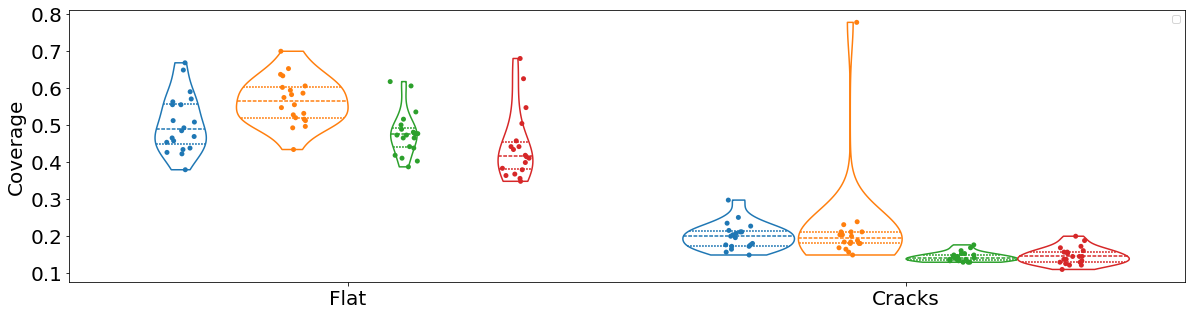

In [ ]:
fig = plt.gcf()
fig.set_size_inches(20,5)
ax = sns.violinplot(fit_max_data,x="environment",hue="encoding",y="fitness",fill=False,inner="quart", cut=0)
sns.stripplot(fit_max_data,x="environment",hue="encoding",y="fitness",dodge=True, jitter=True, legend=False)
h,l = ax.get_legend_handles_labels();
ax.legend(h,[])
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/exploration_score.png")


# Best Robots plots

In [589]:
top_percent = 0.1

df_top_10 = []
for idx, exp in enumerate(experiments["name"]):
     df_tmp = desc_data[desc_data.environment.isin([exp])]
     for rep in df_tmp["replicate"].drop_duplicates():
          df_tmp1 = df_tmp.loc[df_tmp["replicate"] == rep]
          df_top_tmp = df_tmp1.sort_values(by='fitness', ascending=False)
          df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
          # print(exp,len(df_top_tmp),df_top_tmp.max()["fitness"],df_top_tmp.min()["fitness"])
          df_top_10.append(df_top_tmp)

df_top_10 = pd.concat(df_top_10).reset_index(drop=True)

print(df_top_10)

      robot index     width     depth    height    voxels  wheels  sensors  \
0            1880  0.727273  0.545455  0.000000  0.021037     3.0      2.0   
1           10262  0.909091  0.545455  0.181818  0.028550     4.0      2.0   
2            9513  0.727273  0.545455  0.000000  0.021037     3.0      1.0   
3            9032  0.545455  0.545455  0.000000  0.018032     5.0      2.0   
4            3215  0.727273  0.545455  0.090909  0.024042     2.0      3.0   
...           ...       ...       ...       ...       ...     ...      ...   
1593         6417  0.909091  0.909091  0.545455  0.171300     0.0      3.0   
1594         9747  0.545455  0.545455  0.000000  0.018032     3.0      0.0   
1595         5646  0.909091  0.727273  0.181818  0.054095     1.0      0.0   
1596         6697  0.545455  0.545455  0.000000  0.018032     2.0      0.0   
1597        10984  0.545455  0.545455  0.000000  0.018032     4.0      1.0   

      limbs  casters      norm  ...  components norm  replicate

In [590]:
df_top_10_dual_cppn = df_top_10[df_top_10['encoding'] == 'DUAL_CPPN']
for env in experiments['name']:
    print('=============',env,'=============')
    df_top_10_dual_cppn[df_top_10_dual_cppn['environment'] == env].to_csv("dual_cppn_"+env+"_top_10.csv")

============= flat =============
============= cracks =============


In [591]:
df_top_10_me_dual_cppn = df_top_10[df_top_10['encoding'] == 'ME_DUAL_CPPN']
for env in experiments['name']:
    print('=============',env,'=============')
    df_top_10_me_dual_cppn[df_top_10_me_dual_cppn['environment'] == env].to_csv("me_dual_cppn_"+env+"_top_10.csv")

============= flat =============
============= cracks =============


In [592]:
df_top_10_me_sq_cppn = df_top_10[df_top_10['encoding'] == 'ME_SQ_CPPN']
for env in experiments['name']:
    print('=============',env,'=============')
    df_top_10_me_sq_cppn[df_top_10_me_sq_cppn['environment'] == env].to_csv("me_sq_cppn_"+env+"_top_10.csv")

============= flat =============
============= cracks =============


In [593]:
df_top_10_sq_cppn = df_top_10[df_top_10['encoding'] == 'SQ_CPPN']
for env in experiments['name']:
    print('=============',env,'=============')
    df_top_10_sq_cppn[df_top_10_sq_cppn['environment'] == env].to_csv("sq_cppn_"+env+"_top_10.csv")

============= flat =============
============= cracks =============


## Trajectories Plot

In [626]:
traj_data = []
for(replicate, id, env,enc) in zip(df_top_10["replicate"],df_top_10["robot index"],df_top_10["environment"],df_top_10["encoding"]):#,df_top_10["encoding"]):
    traj = medf.load_trajectory(replicate + "/traj_" + str(id))
    traj_data = traj_data + [[id,enc,env] + t for t in traj]
traj_df = pd.DataFrame(traj_data, columns=["robot index","encoding","environment", "time", "x", "y", "z"])

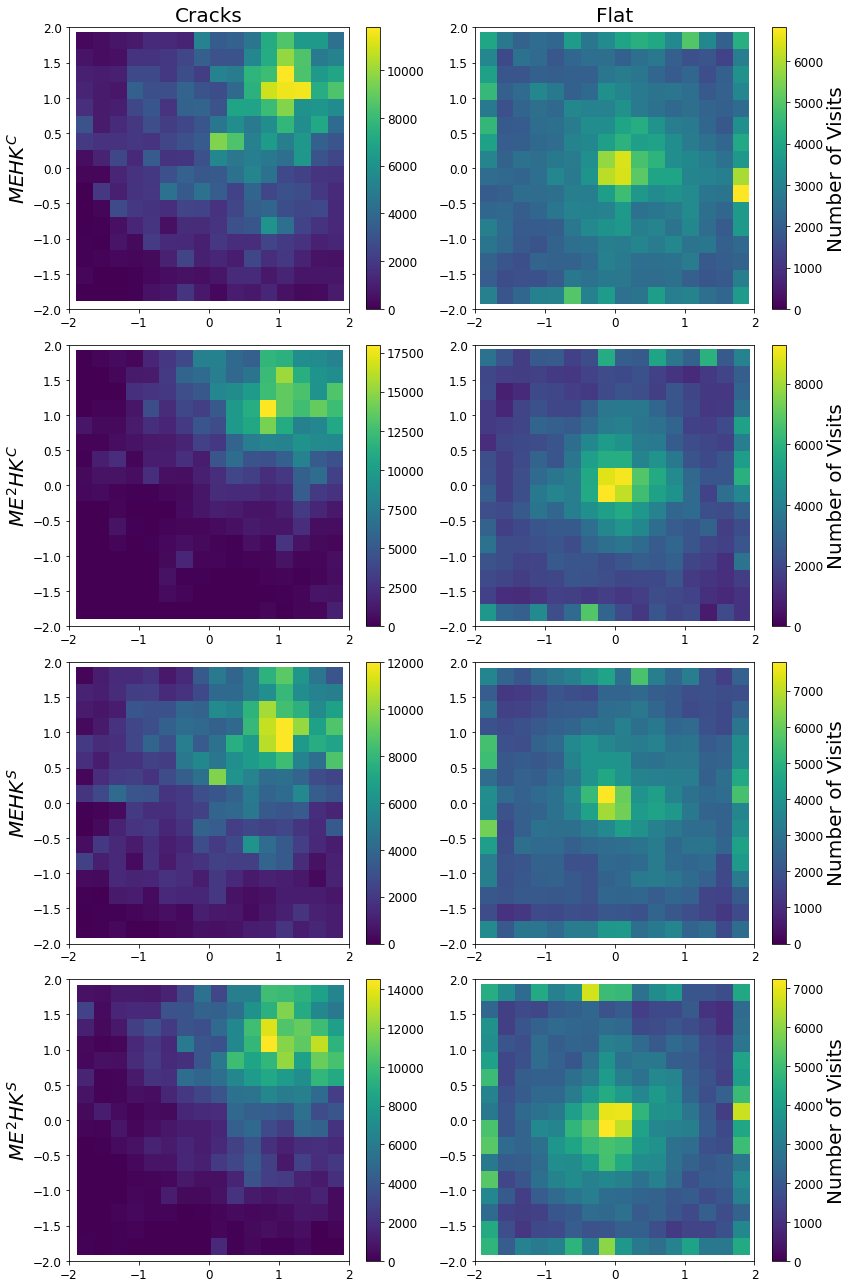

In [628]:
fig, axes = plt.subplots(len(traj_df['encoding'].unique()), len(traj_df['environment'].unique()), figsize=(12, 18))

encodings = ["DUAL_CPPN","ME_DUAL_CPPN","SQ_CPPN","ME_SQ_CPPN"]
environments = sorted(traj_df['environment'].unique())
enc_labels = ["$MEHK^C$","$ME^2HK^C$","$MEHK^S$","$ME^2HK^S$"]
env_labels = ["Cracks","Flat"]
for enc_idx, encoding in enumerate(encodings):
    for env_idx, environment in enumerate(environments):
        ax = axes[enc_idx, env_idx]
        data = traj_df[(traj_df['encoding'] == encoding) & (traj_df['environment'] == environment)]
        
        # Create 2D histogram (heatmap) of x, y positions
        h = ax.hist2d(data['x'], data['y'], bins=16, cmap='viridis',vmin=0)
        
        if enc_idx == 0:
            ax.set_title(env_labels[env_idx], fontsize=20)
        if env_idx == 0:
            ax.set_ylabel(enc_labels[enc_idx], fontsize=20)

        # ax.set_xlabel('X', fontsize=12)
        # ax.set_ylabel('Y', fontsize=12)
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.tick_params(labelsize=12)
        cbar = plt.colorbar(h[3], ax=ax)
        cbar.ax.tick_params(labelsize=12)

        if(env_idx == len(environments)-1):
            cbar.set_label("Number of Visits", fontsize=20)

plt.tight_layout()
plt.savefig("img_gecco26/trajectory_heatmap_xy_grid.png", dpi=150, bbox_inches='tight')
plt.show()

## Components distribution

In [606]:
top_percent = 1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_tmp = desc_data[desc_data.environment.isin([exp])]
     for rep in df_tmp["replicate"].drop_duplicates():
          df_tmp1 = df_tmp.loc[df_tmp["replicate"] == rep]
          df_top_tmp = df_tmp1.sort_values(by='fitness', ascending=False)
          df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
          # print(exp,len(df_top_tmp),df_top_tmp.max()["fitness"],df_top_tmp.min()["fitness"])
          df_top.append(df_top_tmp)

df_top = pd.concat(df_top).reset_index(drop=True)

print(df_top)

       robot index     width     depth    height    voxels  wheels  sensors  \
0             1880  0.727273  0.545455  0.000000  0.021037     3.0      2.0   
1            10262  0.909091  0.545455  0.181818  0.028550     4.0      2.0   
2             9513  0.727273  0.545455  0.000000  0.021037     3.0      1.0   
3             9032  0.545455  0.545455  0.000000  0.018032     5.0      2.0   
4             3215  0.727273  0.545455  0.090909  0.024042     2.0      3.0   
...            ...       ...       ...       ...       ...     ...      ...   
15988         2829  0.727273  0.727273  0.909091  0.191585     3.0      0.0   
15989         9520  0.545455  0.545455  0.000000  0.018032     3.0      0.0   
15990         3089  0.909091  0.909091  0.636364  0.191585     1.0      0.0   
15991         1202  0.545455  0.545455  0.000000  0.018032     3.0      0.0   
15992         6881  0.727273  0.727273  0.272727  0.041322     2.0      1.0   

       limbs  casters      norm  ...  components no

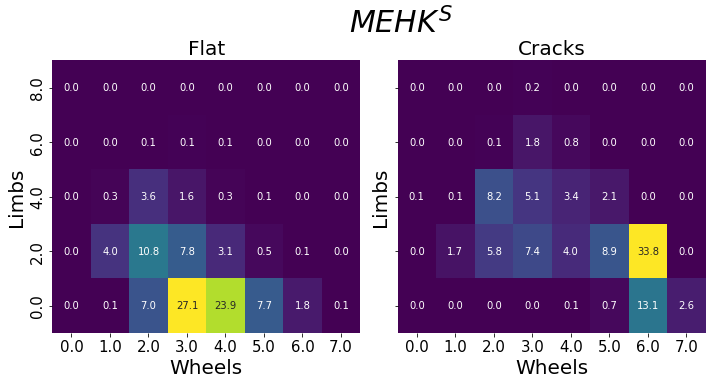

In [607]:
cpy_data = df_top[df_top['encoding'] == 'SQ_CPPN']
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=20)
    ax.set_xlabel('Wheels', fontsize=20)
    ax.set_ylabel('Limbs', fontsize=20)
    ax.invert_yaxis()
    ax.tick_params(labelsize=15)
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1),)
    # ax.set_xticklabels(fontsize=12)
    # ax.set_yticklabels(fontsize=12)
plt.tight_layout()
plt.text(s="$MEHK^S$",x=-1.25,y=5.5,fontsize=30)
plt.savefig("img_gecco26/sq_joints_wheels.png")

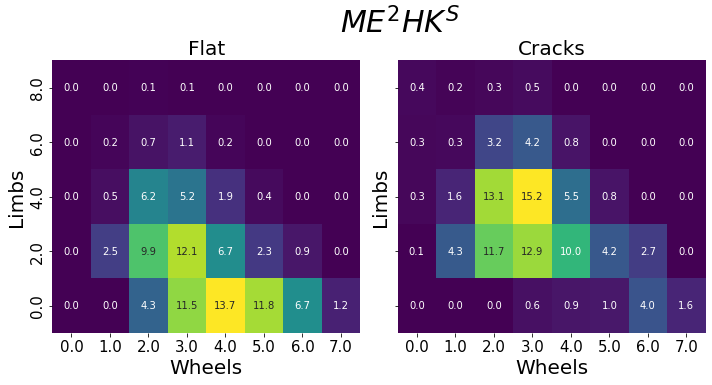

In [608]:
cpy_data = df_top[df_top['encoding'] == 'ME_SQ_CPPN']
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=20)
    ax.set_xlabel('Wheels', fontsize=20)
    ax.set_ylabel('Limbs', fontsize=20)
    ax.invert_yaxis()
    ax.tick_params(labelsize=15)
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()
plt.text(s="$ME^2HK^S$",x=-1.5,y=5.5,fontsize=30)
plt.savefig("img_gecco26/me_sq_joints_wheels.png")

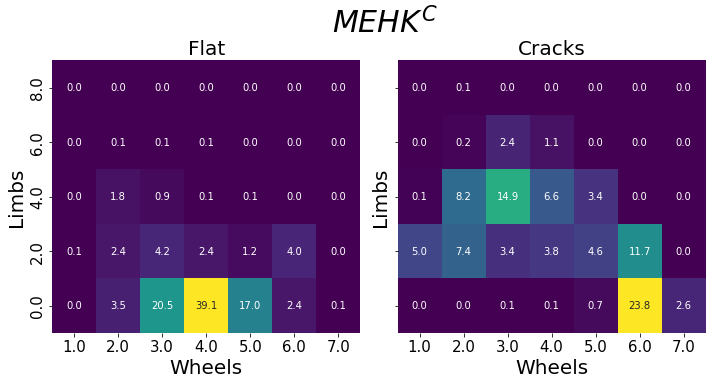

In [609]:
cpy_data = df_top[df_top['encoding'] == 'DUAL_CPPN']
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=20)
    ax.set_xlabel('Wheels', fontsize=20)
    ax.set_ylabel('Limbs', fontsize=20)
    ax.invert_yaxis()
    ax.tick_params(labelsize=15)
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()
plt.text(s="$MEHK^C$",x=-1.5,y=5.5,fontsize=30)
plt.savefig("img_gecco26/cppn_joints_wheels.png")

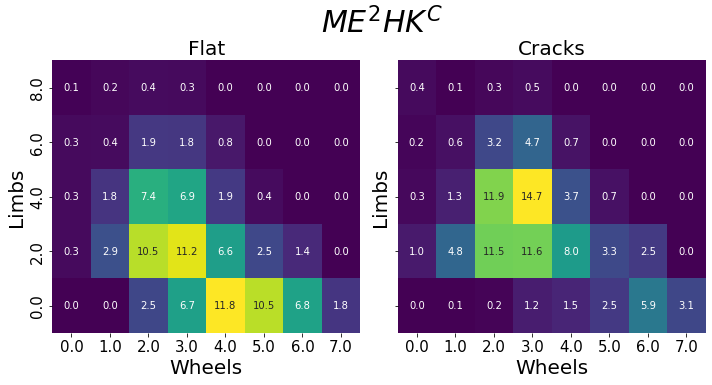

In [610]:
cpy_data = df_top[df_top['encoding'] == 'ME_DUAL_CPPN']
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=20)
    ax.set_xlabel('Wheels', fontsize=20)
    ax.set_ylabel('Limbs', fontsize=20)
    ax.invert_yaxis()
    ax.tick_params(labelsize=15)
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()
plt.text(s="$ME^2HK^C$",x=-2,y=5.5,fontsize=30)
plt.savefig("img_gecco26/me_cppn_joints_wheels.png")

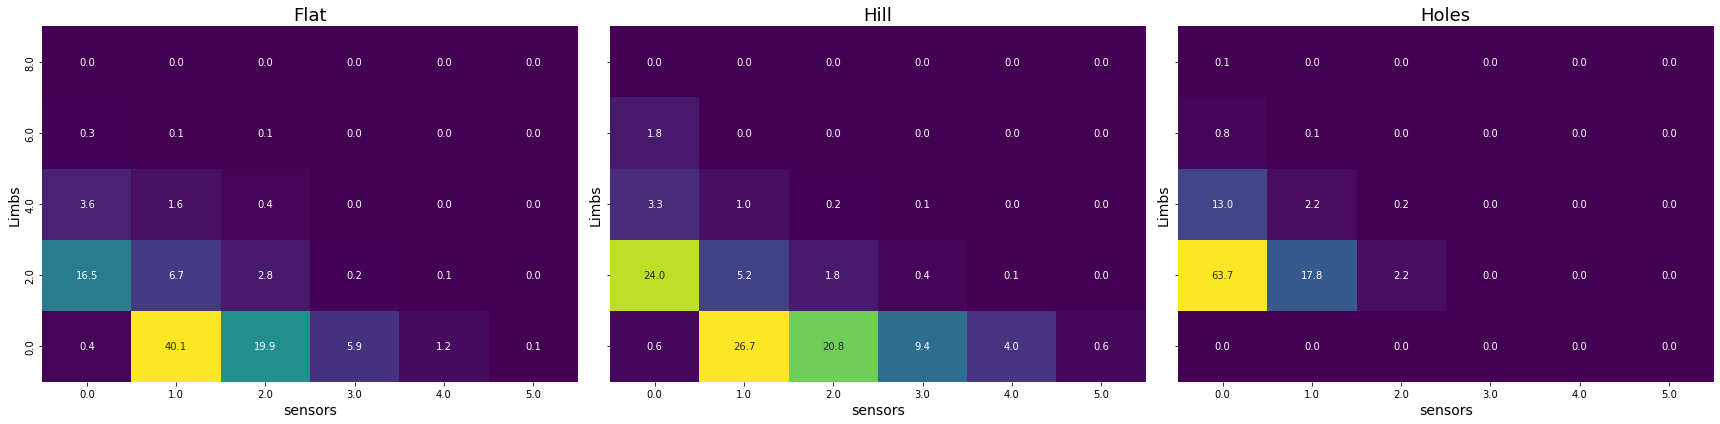

In [ ]:
cpy_data = df_top[df_top['encoding'] == 'SQ_CPPN']
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['sensors'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['sensors'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('sensors', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

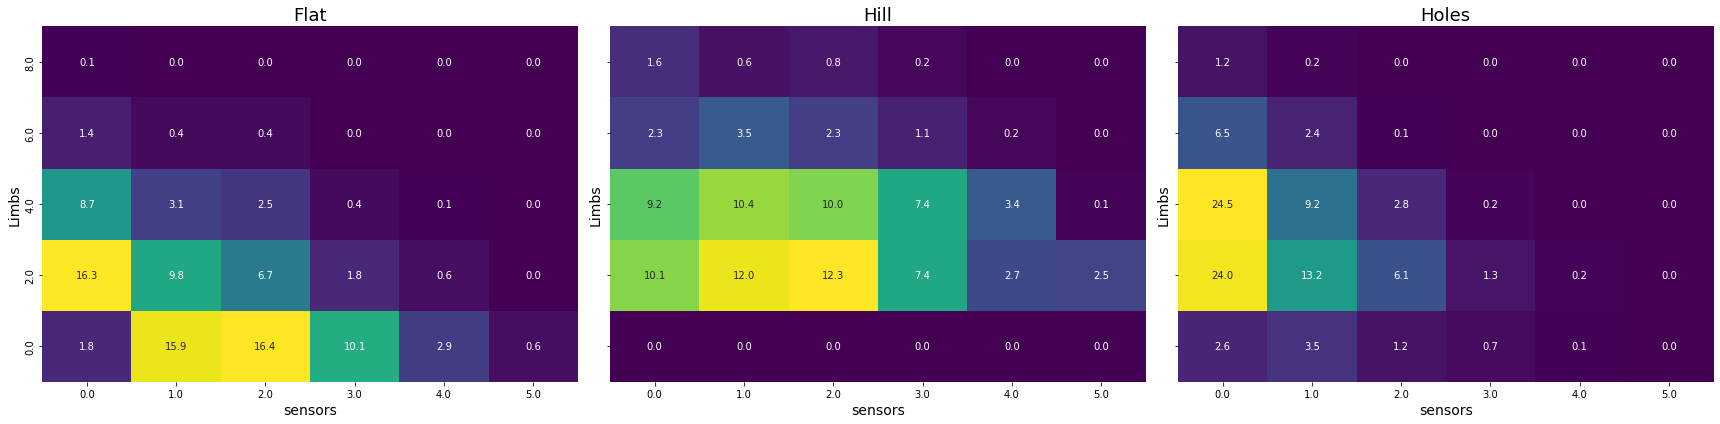

In [212]:
cpy_data = df_top[df_top['encoding'] == 'ME_SQ_CPPN']
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['sensors'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['sensors'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('sensors', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

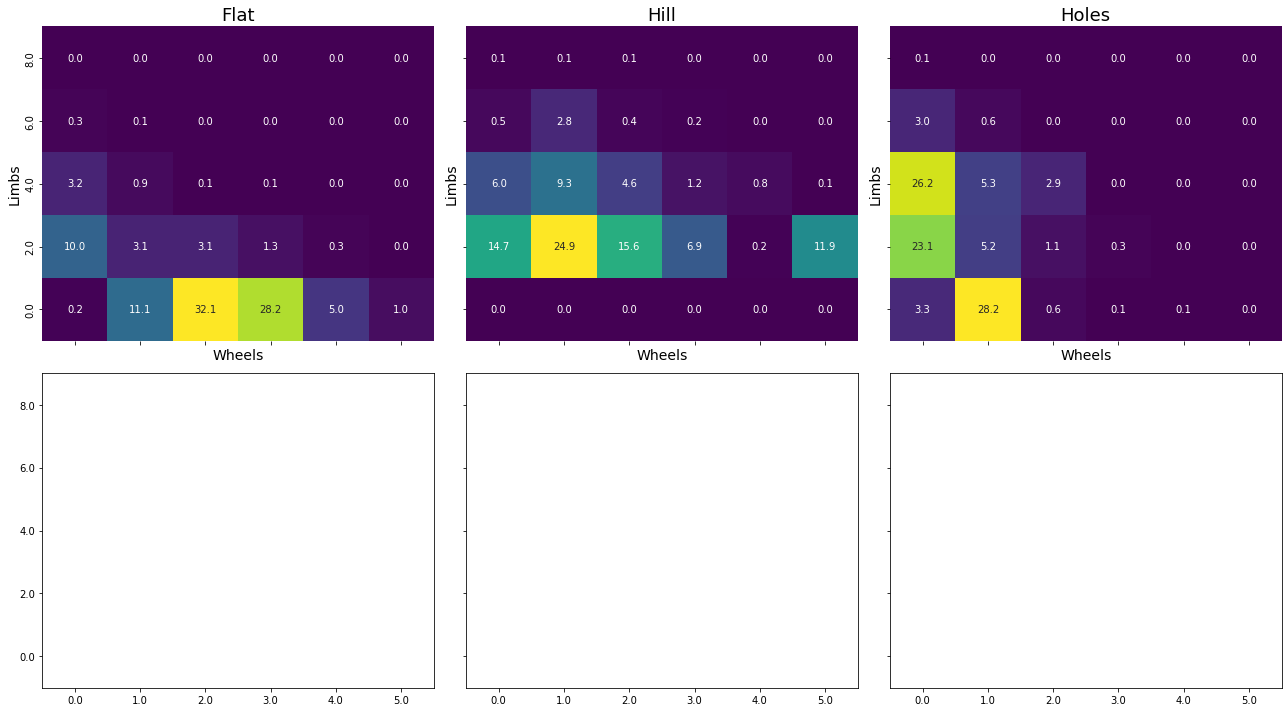

In [213]:
cpy_data = df_top[df_top['encoding'] == 'DUAL_CPPN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['sensors'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['sensors'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

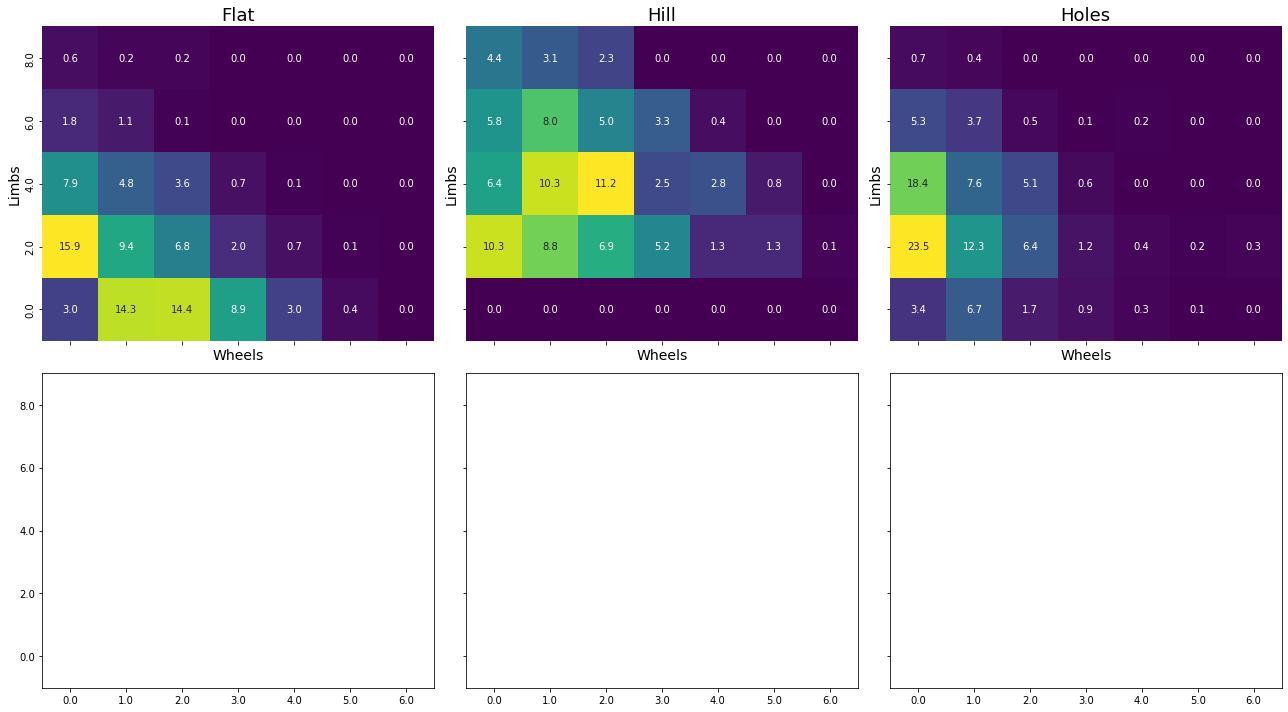

In [214]:
cpy_data = df_top[df_top['encoding'] == 'ME_DUAL_CPPN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['sensors'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['sensors'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

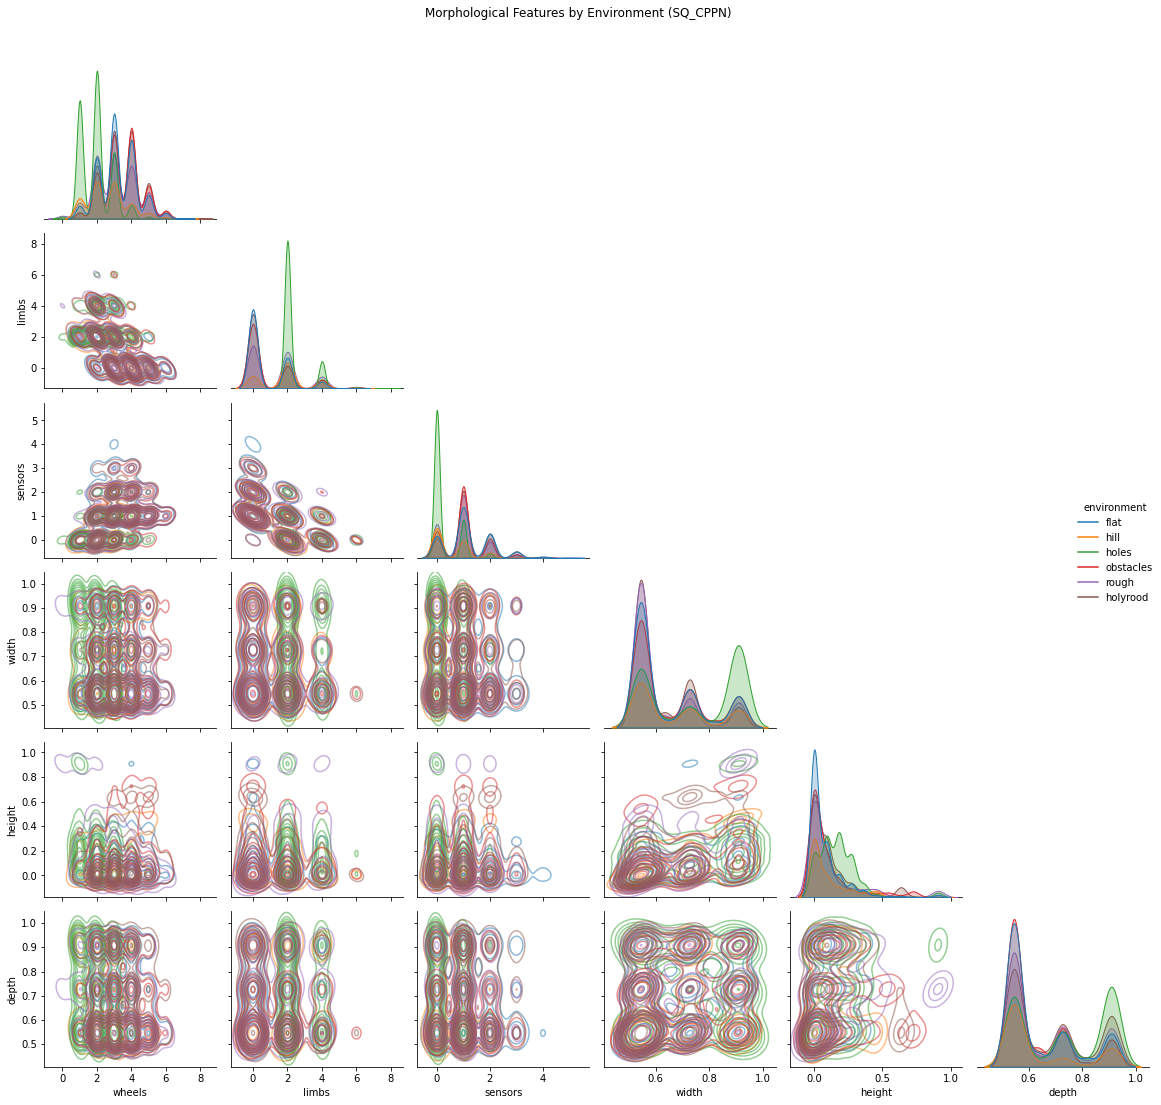

In [24]:
# Select the relevant columns and filter for SQ_CPPN encoding
cols = ['wheels', 'limbs', 'sensors', 'width', 'height', 'depth']
df_sq = df_top[df_top['encoding'] == 'SQ_CPPN']


# Create pairplot with environment as hue
g = sns.pairplot(df_sq, 
                 vars=cols,
                 hue='environment',
                 kind='kde',
                #  diag_kind='hist',
                 plot_kws={'alpha': 0.5},
                 height=2.5,
                 corner=True)

# Adjust layout and title
g.fig.suptitle('Morphological Features by Environment (SQ_CPPN)', y=1.02)
plt.tight_layout()

# Save figure
plt.savefig("img_alife25/morphological_features_by_env_pairplot.png", bbox_inches='tight', dpi=150)
plt.show()

       robot index     width     depth    height    voxels  wheels  sensors  \
2000          2306  0.909091  0.727273  0.909091  0.125470     3.0      4.0   
2001          6861  0.545455  0.545455  0.000000  0.018032     6.0      0.0   
2002          6259  0.545455  0.545455  0.000000  0.018032     5.0      0.0   
2003          2153  0.545455  0.545455  0.000000  0.018032     3.0      0.0   
2004          5545  0.545455  0.545455  0.000000  0.018032     6.0      0.0   
...            ...       ...       ...       ...       ...     ...      ...   
14680         2505  0.545455  0.545455  0.000000  0.018032     4.0      1.0   
14681        10088  0.545455  0.545455  0.000000  0.018032     4.0      3.0   
14682          698  0.545455  0.545455  0.000000  0.018032     3.0      0.0   
14683         8593  0.545455  0.545455  0.000000  0.018032     4.0      3.0   
14684         9863  0.545455  0.545455  0.000000  0.018032     4.0      3.0   

       limbs  casters      norm  ...  components no

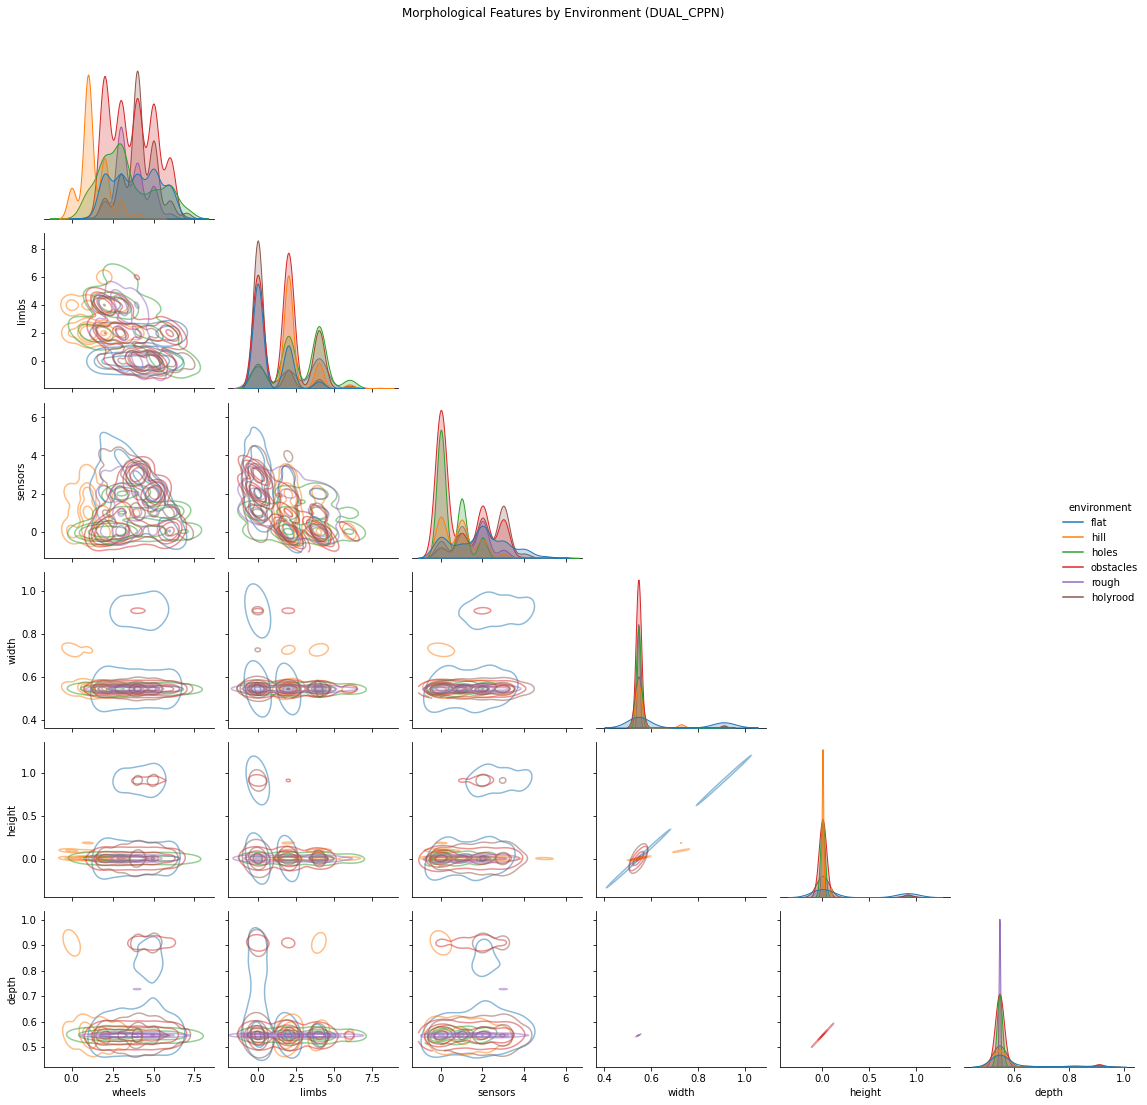

In [29]:
# Select the relevant columns and filter for DUAL_CPPN encoding
cols = ['wheels', 'limbs', 'sensors', 'width', 'height', 'depth']
df_sq = df_top[df_top['encoding'] == 'DUAL_CPPN']
print(df_sq)

# Create pairplot with environment as hue
g = sns.pairplot(df_sq, 
                 vars=cols,
                 hue='environment',
                 kind='kde',
                #  diag_kind='hist',
                 plot_kws={'alpha': 0.5,'levels':5},
                 height=2.5,corner=True)

# Adjust layout and title
g.fig.suptitle('Morphological Features by Environment (DUAL_CPPN)', y=1.02)
plt.tight_layout()

# Save figure
plt.savefig("img_alife25/morphological_features_by_env_pairplot.png", bbox_inches='tight', dpi=150)
plt.show()

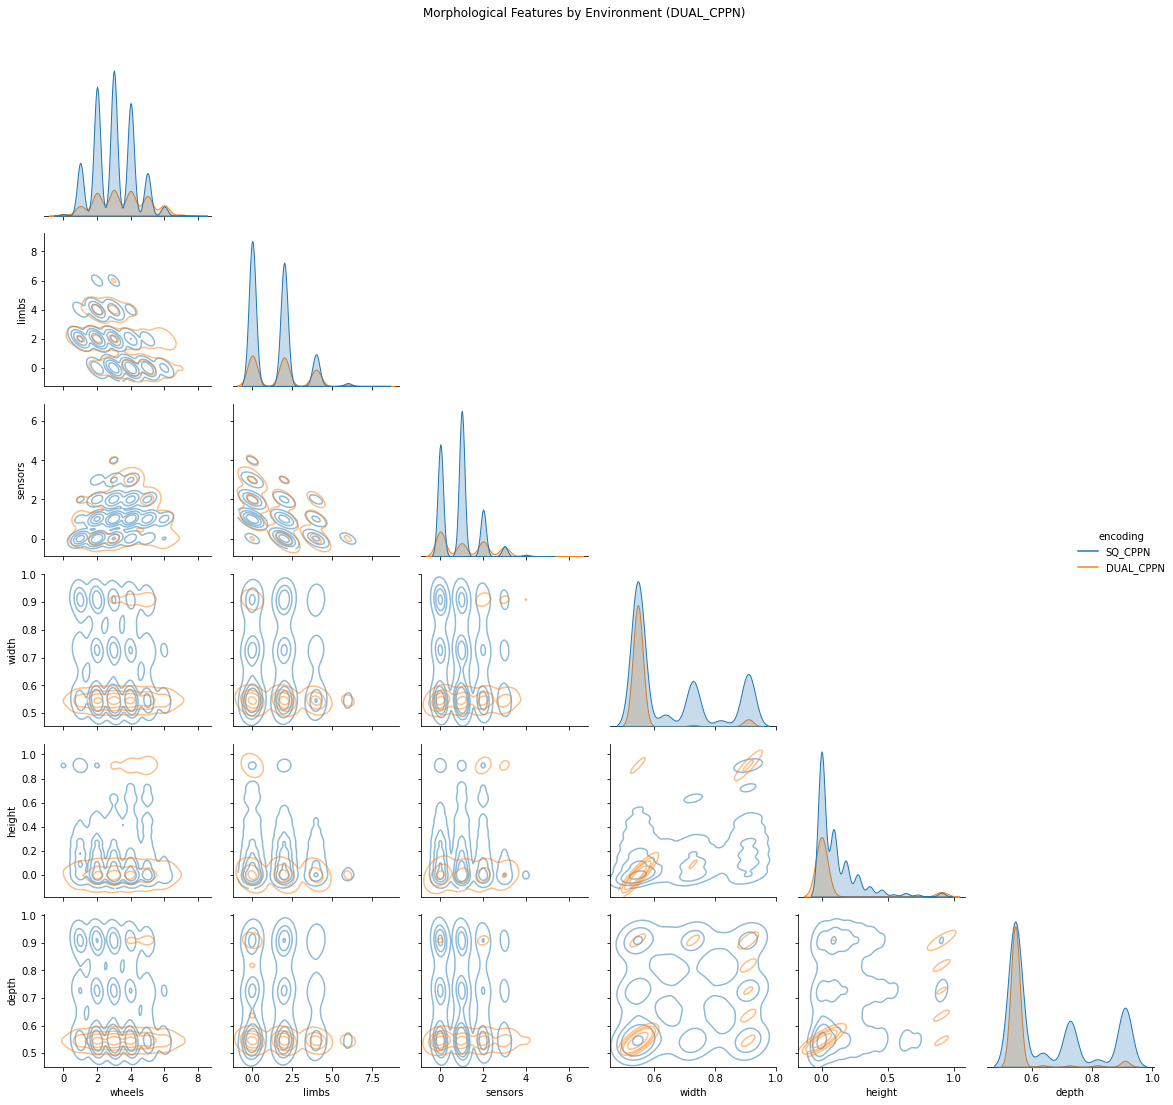

In [34]:
# Select the relevant columns and filter for DUAL_CPPN encoding
cols = ['wheels', 'limbs', 'sensors', 'width', 'height', 'depth']
# df_sq = df_top[df_top['encoding'] == 'DUAL_CPPN']

# Create pairplot with environment as hue
g = sns.pairplot(df_top, 
                 vars=cols,
                 hue='encoding',
                 kind='kde',
                #  diag_kind='hist',
                 plot_kws={'alpha': 0.5,'levels':5},
                 height=2.5,corner=True)

# Adjust layout and title
g.fig.suptitle('Morphological Features by Environment (DUAL_CPPN)', y=1.02)
plt.tight_layout()

# Save figure
plt.savefig("img_alife25/morphological_features_by_env_pairplot.png", bbox_inches='tight', dpi=150)
plt.show()

# Map-elites plots

In [ ]:
# PairGrid showing only bottom half (corner=True) with histograms on diagonal.
# This version uses max fitness per bin instead of average.

def plot_map_elites(me_data, env_name, encoding, title):
    cols = ['wheels', 'limbs', 'sensors', 'width', 'height', 'depth']
    bins = {'wheels':8, 'limbs':6, 'sensors':8, 'width':6, 'height':12, 'depth':6}

    # select data
    df_plot = me_data[(me_data['environment'] == env_name) & (me_data['encoding'] == encoding)][cols + ['fitness']].dropna().copy()
    if df_plot.empty:
        print("No data for", env_name, encoding)
        return

    # compute fitness color range
    vmin = 0
    vmax = 0.5
    cmap = mpl.cm.brg
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # normalize the selected dimensions to [0,1] for plotting (leave fitness unchanged)
    col_mins = {'wheels':0,'limbs':0,'sensors':0,'width':0.5,'height':0,'depth':0.5}
    col_maxs = {'wheels':8,'limbs':12,'sensors':8,'width':1,'height':1,'depth':1}
    df_norm = df_plot.copy()
    for c in cols:
        lo = col_mins[c]
        hi = col_maxs[c]
        if hi > lo:
            df_norm[c] = (df_plot[c] - lo) / (hi - lo)
        else:
            # constant column -> set to middle (0.5) to avoid degenerate bins
            df_norm[c] = 0.5

    g = sns.PairGrid(df_norm, vars=cols, diag_sharey=False, height=2.5, corner=True)

    _last_mappable = {'obj': None}

    # precompute edges for each column using the per-dimension bin counts
    edges_dict = {c: np.linspace(0.0, 1.0, bins[c] + 1) for c in cols}

    def _diag_max_hist(x, **kwargs):
        # Use per-variable edges
        edges = edges_dict.get(x.name, np.linspace(0.0, 1.0, 11))
        fitness = df_norm.loc[x.index, 'fitness'].values
        ax = plt.gca()
        counts, bin_edges = np.histogram(x, bins=edges)
        inds = np.digitize(x, bin_edges, right=False)
        centers = bin_edges[:-1] + np.diff(bin_edges) / 2.0

        maxvals = np.full(len(counts), np.nan)
        for b in range(len(counts)):
            mask = (inds == b + 1)
            if mask.any():
                maxvals[b] = fitness[mask].max()

        heights = np.nan_to_num(maxvals, nan=0.0)
        colors = cmap(norm(np.nan_to_num(maxvals, nan=vmin)))
        # set color for empty bins to light gray
        for i in range(len(colors)):
            if counts[i] == 0:
                colors[i] = (0.9, 0.9, 0.9, 1.0)
        widths = np.diff(edges)
        ax.bar(centers, heights, align='center', width=widths, color=colors, edgecolor='k', linewidth=0.3)
        ax.set_xlabel(xlabel=x.name,fontsize=15)
        ax.set_xlim(edges[0], edges[-1])

        # ax.set_ylabel("max fitness")

    def _lower_max_grid(x, y, **kwargs):
        # use per-variable bin counts / edges
        xedges = edges_dict.get(x.name, np.linspace(0.0, 1.0, 11))
        yedges = edges_dict.get(y.name, np.linspace(0.0, 1.0, 11))
        nx = len(xedges) - 1
        ny = len(yedges) - 1

        fitness = df_plot.loc[x.index, 'fitness'].values
        ax = plt.gca()
        # compute max per bin
        maxgrid = np.full((nx, ny), np.nan)

        x_vals = x.values
        y_vals = y.values
        for i_point in range(len(x_vals)):
            xv = x_vals[i_point]
            yv = y_vals[i_point]
            xi = np.searchsorted(xedges, xv, side='right') - 1
            yi = np.searchsorted(yedges, yv, side='right') - 1
            if 0 <= xi < nx and 0 <= yi < ny:
                cur = maxgrid[xi, yi]
                val = fitness[i_point]
                if np.isnan(cur) or val > cur:
                    maxgrid[xi, yi] = val

        display_grid = maxgrid.T  # transpose for pcolormesh orientation
        mesh = ax.pcolormesh(xedges, yedges, display_grid, cmap=cmap, norm=norm, shading='auto')
        # overlay light gray for empty bins
        empty_mask = np.isnan(display_grid)
        if empty_mask.any():
            for xi in range(nx):
                for yi in range(ny):
                    if empty_mask[yi, xi]:
                        ax.add_patch(plt.Rectangle((xedges[xi], yedges[yi]),
                                                   xedges[xi + 1] - xedges[xi],
                                                   yedges[yi + 1] - yedges[yi],
                                                   color=(0.9, 0.9, 0.9, 1.0),
                                                   ec='none'))
        ax.set_xlim(xedges[0], xedges[-1])
        ax.set_ylim(yedges[0], yedges[-1])
        ax.set_xlabel(xlabel=x.name,fontsize=15)
        ax.set_ylabel(ylabel=y.name,fontsize=15)
        _last_mappable['obj'] = mesh
    

    g.map_diag(_diag_max_hist)
    g.map_lower(_lower_max_grid)

    g.fig.suptitle(title,fontsize=30,y=0.9)
    g.fig.set_size_inches(12, 12)
    for ax in g.axes.flatten():
        if ax is not None:
            ax.tick_params(axis='both', which='major', labelsize=13)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

    if _last_mappable['obj'] is not None:
        mappable = _last_mappable['obj']
        cax = g.fig.add_axes([0.9, 0.15, 0.02, 0.7])
        cbar = g.fig.colorbar(mappable, cax=cax)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label('Max Exploration Score',fontsize=20)

    plt.tight_layout(rect=[0, 0, 0.9, 0.97])
    plt.savefig("img_gecco26/pairplot_map_me2hk_max_fitness_" + encoding + "_" + env_name + ".png", bbox_inches='tight', dpi=150)
    plt.show()

## general results

/tmp/ipykernel_39650/280903359.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.get_text() for l in ax.get_xticklabels()])


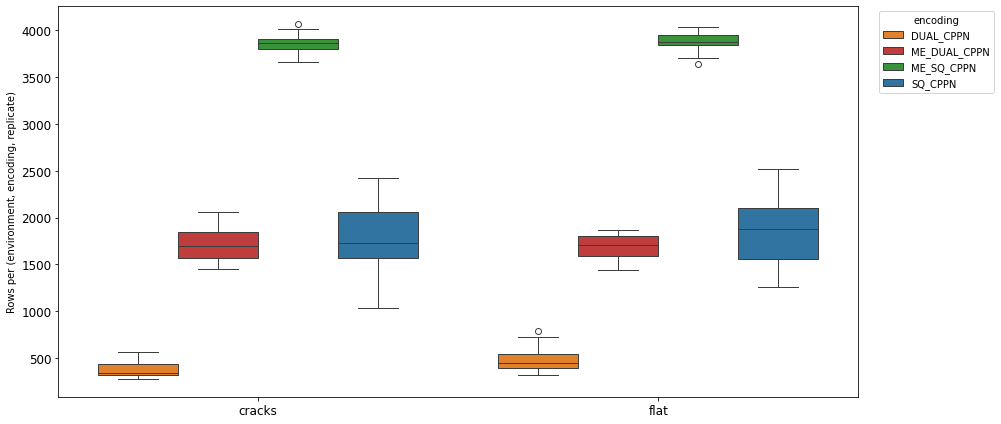

In [598]:
# boxplot of number of rows per (environment, encoding, replicate)
counts = me_data.groupby(['environment', 'encoding', 'replicate']).size().reset_index(name='n_rows')

plt.figure(figsize=(14,6))
ax = sns.boxplot(data=counts, x='environment', y='n_rows', hue='encoding', showfliers=True,palette={'SQ_CPPN':'C0','DUAL_CPPN':'C1','ME_SQ_CPPN':'C2','ME_DUAL_CPPN':'C3'})
h,l = ax.get_legend_handles_labels()
ax.legend(h,["MEHKᶜ","ME\u00b2HKᶜ","ME\u00b2HKˢ","MEHKˢ"])
ax.set_xlabel('')
ax.set_ylabel('Rows per (environment, encoding, replicate)')
ax.set_xticklabels([l.get_text() for l in ax.get_xticklabels()])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='encoding', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("img_gecco26/rows_per_replicate_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_39650/304026272.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Encoding', bbox_to_anchor=(1.05, 1), loc='upper left')


<Figure size 1008x504 with 0 Axes>

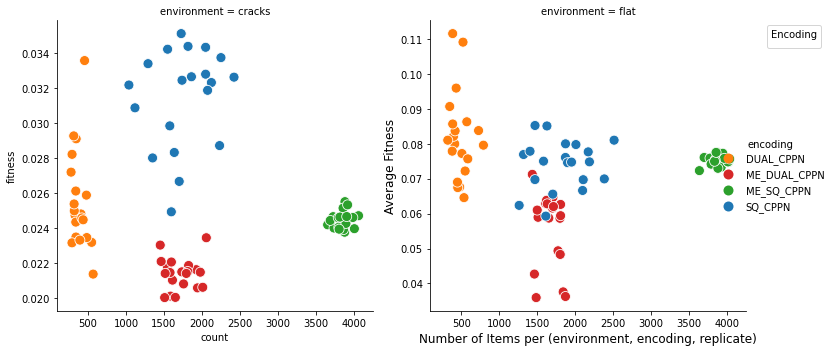

In [599]:
# Calculate average fitness per environment, encoding, and replicate
avg_fitness_per_group = me_data.groupby(['environment', 'encoding', 'replicate']).agg({
    'fitness': 'mean'
}).reset_index()

# Get count of items per group
counts_per_group = me_data.groupby(['environment', 'encoding', 'replicate']).size().reset_index(name='count')

# Merge the two
plot_data = avg_fitness_per_group.merge(counts_per_group, on=['environment', 'encoding', 'replicate'])

# Create scatterplot
fig = plt.figure(figsize=(14, 7))
sns.relplot(data=plot_data, x='count', y='fitness', hue='encoding', col="environment", s=100,facet_kws={'sharey': False, 'sharex': True},palette={'SQ_CPPN':'C0','DUAL_CPPN':'C1','ME_SQ_CPPN':'C2','ME_DUAL_CPPN':'C3'})
plt.xlabel('Number of Items per (environment, encoding, replicate)', fontsize=12)
plt.ylabel('Average Fitness', fontsize=12)
# plt.title('Average Fitness vs Count of Items per Group (one dot per replicate)', fontsize=14)
plt.legend(title='Encoding', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1008x504 with 0 Axes>

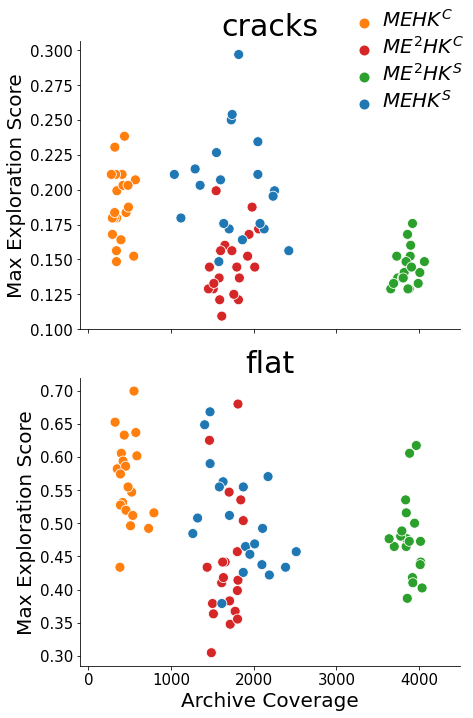

In [604]:
# Calculate average fitness per environment, encoding, and replicate
avg_fitness_per_group = me_data.groupby(['environment', 'encoding', 'replicate']).agg({
    'fitness': 'max'
}).reset_index()

# Get count of items per group
counts_per_group = me_data.groupby(['environment', 'encoding', 'replicate']).size().reset_index(name='count')

# Merge the two
plot_data = avg_fitness_per_group.merge(counts_per_group, on=['environment', 'encoding', 'replicate'])

# Create scatterplot
fig = plt.figure(figsize=(14, 7))
fg = sns.relplot(data=plot_data, x='count', y='fitness', hue='encoding', row="environment", s=100,facet_kws={'sharey': False},palette={'SQ_CPPN':'C0','DUAL_CPPN':'C1','ME_SQ_CPPN':'C2','ME_DUAL_CPPN':'C3'})
sns.move_legend(fg,loc="upper right")
fg.legend.set_title("")
fg.legend.get_texts()[0].set_text("$MEHK^C$")
fg.legend.get_texts()[1].set_text("$ME^2HK^C$")
fg.legend.get_texts()[2].set_text("$ME^2HK^S$")
fg.legend.get_texts()[3].set_text("$MEHK^S$")
for text in fg.legend.texts:
    text.set_fontsize(20)
fg.set_axis_labels("Archive Coverage","Max Exploration Score",fontsize=20)
fg.set(xlim=(-100,4500))
fg.tick_params(labelsize=15)

fg.set_titles(row_template="{row_name}",size=30)

# plt.xlabel('Number of Items per (environment, encoding, replicate)', fontsize=12)
# plt.ylabel('Max Fitness', fontsize=12)
# plt.title('Average Fitness vs Count of Items per Group (one dot per replicate)', fontsize=14)

plt.tight_layout()
plt.savefig("img_gecco26/qd_coverage_max_fitness.png", dpi=150, bbox_inches='tight')
plt.show()


<Figure size 1008x504 with 0 Axes>

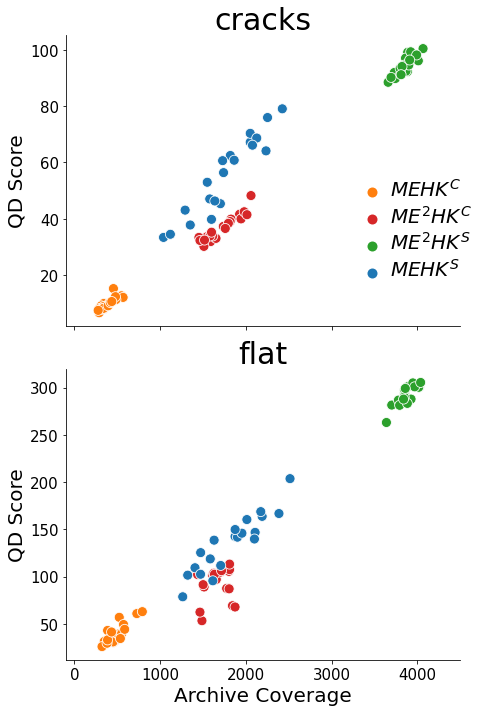

In [605]:
# Calculate average fitness per environment, encoding, and replicate
avg_fitness_per_group = me_data.groupby(['environment', 'encoding', 'replicate']).agg({
    'fitness': 'sum'
}).reset_index()

# Get count of items per group
counts_per_group = me_data.groupby(['environment', 'encoding', 'replicate']).size().reset_index(name='count')

# Merge the two
plot_data = avg_fitness_per_group.merge(counts_per_group, on=['environment', 'encoding', 'replicate'])

# Create scatterplot
fig = plt.figure(figsize=(14, 7))
fg = sns.relplot(data=plot_data, x='count', y='fitness', hue='encoding', row="environment",s=100,facet_kws={'sharey': False, 'sharex': True},palette={'SQ_CPPN':'C0','DUAL_CPPN':'C1','ME_SQ_CPPN':'C2','ME_DUAL_CPPN':'C3'})
sns.move_legend(fg,loc=(0.75,0.6))
fg.legend.set_title("")
fg.legend.get_texts()[0].set_text("$MEHK^C$")
fg.legend.get_texts()[1].set_text("$ME^2HK^C$")
fg.legend.get_texts()[2].set_text("$ME^2HK^S$")
fg.legend.get_texts()[3].set_text("$MEHK^S$")
for text in fg.legend.texts:
    text.set_fontsize(20)
fg.set_axis_labels("Archive Coverage","QD Score",fontsize=20)
fg.tick_params(labelsize=15)
fg.set_titles(row_template="{row_name}",size=30)
fg.set(xlim=(-100,4500))
# plt.xlabel('Number of Items per (environment, encoding, replicate)', fontsize=12)
# plt.ylabel('Max Fitness', fontsize=12)
# plt.title('Average Fitness vs Count of Items per Group (one dot per replicate)', fontsize=14)

plt.tight_layout()
plt.savefig("img_gecco26/qd_coverage_qd_score.png", dpi=150, bbox_inches='tight')
plt.show()

In [619]:

summary_stats = me_data.groupby(['environment', 'encoding', 'replicate']).agg({
    'fitness': ['sum',"mean", 'max', 'count'],
}).reset_index()

# Flatten column names
summary_stats.columns = ['_'.join(col).strip('_') for col in summary_stats.columns.values]

print("QD Score mean: ",summary_stats.groupby(['environment', 'encoding'])['fitness_sum'].mean(),"\nstd: ",summary_stats.groupby(['environment', 'encoding'])['fitness_sum'].std())
print("Max fitness mean: ",summary_stats.groupby(['environment', 'encoding'])['fitness_max'].mean(),"\nstd: ",summary_stats.groupby(['environment', 'encoding'])['fitness_max'].std())

print("Average fitness mean: ",summary_stats.groupby(['environment', 'encoding'])['fitness_mean'].mean(),"\nstd: ",summary_stats.groupby(['environment', 'encoding'])['fitness_mean'].std())
print("Archive Coverage mean: ",summary_stats.groupby(['environment', 'encoding'])['fitness_count'].mean(),"\nstd: ",summary_stats.groupby(['environment', 'encoding'])['fitness_count'].std())

QD Score mean:  environment  encoding    
cracks       DUAL_CPPN         9.743557
             ME_DUAL_CPPN     36.773446
             ME_SQ_CPPN       94.303142
             SQ_CPPN          55.617779
flat         DUAL_CPPN        39.429297
             ME_DUAL_CPPN     92.563671
             ME_SQ_CPPN      291.974793
             SQ_CPPN         135.655271
Name: fitness_sum, dtype: float64 
std:  environment  encoding    
cracks       DUAL_CPPN        2.152428
             ME_DUAL_CPPN     4.569717
             ME_SQ_CPPN       3.399882
             SQ_CPPN         13.952173
flat         DUAL_CPPN       10.699286
             ME_DUAL_CPPN    17.126029
             ME_SQ_CPPN      10.400704
             SQ_CPPN         30.236139
Name: fitness_sum, dtype: float64
Max fitness mean:  environment  encoding    
cracks       DUAL_CPPN       0.189844
             ME_DUAL_CPPN    0.146289
             ME_SQ_CPPN      0.143750
             SQ_CPPN         0.202344
flat         DUAL_CPPN      

In [620]:
print(summary_stats)

    environment   encoding                                          replicate  \
0        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
1        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
2        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
3        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
4        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
..          ...        ...                                                ...   
155        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
156        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
157        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
158        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
159        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   

     fitness_sum  fitness_m

In [621]:
import scipy.stats as stats
import cliffs_delta as cd

print("FLAT ARENA STATISTICAL TESTS")
summary_stats_flat = summary_stats[summary_stats['environment'] == 'flat']

print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']))
print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']))
print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']))
print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']))

print("QD SCORE STATISTICAL TESTS")
print("SQ_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print("SQ_CPPN VS DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum'])))
print("SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print("DUAL_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print("DUAL_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print("ME_SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))

print("MAX FITNESS STATISTICAL TESTS")
print("SQ_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print("SQ_CPPN VS DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max']))) 
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max'])))                
print("SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))     
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))    
print("DUAL_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print("DUAL_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))         
print("ME_SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))

print("ARCHIVE COVERAGE STATISTICAL TESTS")
print("SQ_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print("SQ_CPPN VS DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count']))) 
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count'])))        
print("SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))         
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print("DUAL_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print("DUAL_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print("ME_SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count']),
               list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))

FLAT ARENA STATISTICAL TESTS
20
20
20
20
QD SCORE STATISTICAL TESTS
SQ_CPPN VS ME_SQ_CPPN MannwhitneyuResult(statistic=0.0, pvalue=6.795615128173358e-08)
 Effect size:  (-1.0, 'large')
SQ_CPPN VS DUAL_CPPN MannwhitneyuResult(statistic=400.0, pvalue=6.795615128173358e-08)
 Effect size:  (1.0, 'large')
SQ_CPPN VS ME_DUAL_CPPN MannwhitneyuResult(statistic=354.0, pvalue=3.293105907732221e-05)
 Effect size:  (0.77, 'large')
DUAL_CPPN VS ME_SQ_CPPN MannwhitneyuResult(statistic=0.0, pvalue=6.795615128173358e-08)
 Effect size:  (-1.0, 'large')
DUAL_CPPN VS ME_DUAL_CPPN MannwhitneyuResult(statistic=4.0, pvalue=1.2346350154956704e-07)
 Effect size:  (-0.98, 'large')
ME_SQ_CPPN VS ME_DUAL_CPPN MannwhitneyuResult(statistic=400.0, pvalue=6.795615128173358e-08)
 Effect size:  (1.0, 'large')
MAX FITNESS STATISTICAL TESTS
SQ_CPPN VS ME_SQ_CPPN MannwhitneyuResult(statistic=234.5, pvalue=0.3574797941879335)
 Effect size:  (0.1725, 'small')
SQ_CPPN VS DUAL_CPPN MannwhitneyuResult(statistic=103.5, pvalue=

In [622]:
import scipy.stats as stats
import cliffs_delta as cd

print("CRACKS ARENA STATISTICAL TESTS")
summary_stats_cracks = summary_stats[summary_stats['environment'] == 'cracks']

print(len(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']))
print(len(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']))
print(len(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']))
print(len(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']))

print("QD SCORE STATISTICAL TESTS")
print("SQ_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print("SQ_CPPN VS DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_sum'])))
print("SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print("DUAL_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))
print("DUAL_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print("ME_SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_sum']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))

print("MAX FITNESS STATISTICAL TESTS")
print("SQ_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print("SQ_CPPN VS DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_max']))) 
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_max']),
                list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_max'])))        
print("SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))         
print("DUAL_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))
print("DUAL_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))                  
print("ME_SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_max']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))

print("ARCHIVE COVERAGE STATISTICAL TESTS")
print("SQ_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print("SQ_CPPN VS DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_count']))) 
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_count']),
                list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_count'])))        
print("SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'SQ_CPPN']['fitness_count']),
                list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))         
print("DUAL_CPPN VS ME_SQ_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))
print("DUAL_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'DUAL_CPPN']['fitness_count']),
                list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))         
print("ME_SQ_CPPN VS ME_DUAL_CPPN",stats.mannwhitneyu(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_count']),
               list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print(" Effect size: ",cd.cliffs_delta(list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_SQ_CPPN']['fitness_count']),
                list(summary_stats_cracks[summary_stats_cracks['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))

CRACKS ARENA STATISTICAL TESTS
20
20
20
20
QD SCORE STATISTICAL TESTS
SQ_CPPN VS ME_SQ_CPPN MannwhitneyuResult(statistic=0.0, pvalue=6.795615128173358e-08)
 Effect size:  (-1.0, 'large')
SQ_CPPN VS DUAL_CPPN MannwhitneyuResult(statistic=400.0, pvalue=6.795615128173358e-08)
 Effect size:  (1.0, 'large')
SQ_CPPN VS ME_DUAL_CPPN MannwhitneyuResult(statistic=356.0, pvalue=2.5959840395871986e-05)
 Effect size:  (0.78, 'large')
DUAL_CPPN VS ME_SQ_CPPN MannwhitneyuResult(statistic=0.0, pvalue=6.795615128173358e-08)
 Effect size:  (-1.0, 'large')
DUAL_CPPN VS ME_DUAL_CPPN MannwhitneyuResult(statistic=0.0, pvalue=6.795615128173358e-08)
 Effect size:  (-1.0, 'large')
ME_SQ_CPPN VS ME_DUAL_CPPN MannwhitneyuResult(statistic=400.0, pvalue=6.795615128173358e-08)
 Effect size:  (1.0, 'large')
MAX FITNESS STATISTICAL TESTS
SQ_CPPN VS ME_SQ_CPPN MannwhitneyuResult(statistic=386.0, pvalue=5.050233276842775e-07)
 Effect size:  (0.93, 'large')
SQ_CPPN VS DUAL_CPPN MannwhitneyuResult(statistic=231.0, pvalu

In [623]:
import scipy.stats as stats

print("FLAT ARENA STATISTICAL TESTS")
summary_stats_flat = summary_stats[summary_stats['environment'] == 'flat']

print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']))
print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']))
print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']))
print(len(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']))

print("QD SCORE STATISTICAL TESTS")
print("SQ_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_sum'])))
print("DUAL_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_sum'])))
print("ME_DUAL_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_sum'])))
print("ME_SQ_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_sum'])))

print("MAX FITNESS STATISTICAL TESTS")
print("SQ_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_max'])))
print("DUAL_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_max'])))
print("ME_DUAL_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_max'])))
print("ME_SQ_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_max'])))

print("ARCHIVE COVERAGE STATISTICAL TESTS")
print("SQ_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'SQ_CPPN']['fitness_count'])))
print("DUAL_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'DUAL_CPPN']['fitness_count'])))
print("ME_DUAL_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_DUAL_CPPN']['fitness_count'])))
print("ME_SQ_CPPN",stats.shapiro(list(summary_stats_flat[summary_stats_flat['encoding'] == 'ME_SQ_CPPN']['fitness_count'])))

FLAT ARENA STATISTICAL TESTS
20
20
20
20
QD SCORE STATISTICAL TESTS
SQ_CPPN ShapiroResult(statistic=0.9764461517333984, pvalue=0.8804888725280762)
DUAL_CPPN ShapiroResult(statistic=0.8655523657798767, pvalue=0.009823160246014595)
ME_DUAL_CPPN ShapiroResult(statistic=0.8820452690124512, pvalue=0.01925985887646675)
ME_SQ_CPPN ShapiroResult(statistic=0.8993664383888245, pvalue=0.04012676700949669)
MAX FITNESS STATISTICAL TESTS
SQ_CPPN ShapiroResult(statistic=0.9530672430992126, pvalue=0.4160582423210144)
DUAL_CPPN ShapiroResult(statistic=0.9877853989601135, pvalue=0.9938044548034668)
ME_DUAL_CPPN ShapiroResult(statistic=0.9045377969741821, pvalue=0.05020204931497574)
ME_SQ_CPPN ShapiroResult(statistic=0.9109392762184143, pvalue=0.06641817837953568)
ARCHIVE COVERAGE STATISTICAL TESTS
SQ_CPPN ShapiroResult(statistic=0.9700152277946472, pvalue=0.7551959753036499)
DUAL_CPPN ShapiroResult(statistic=0.9064424633979797, pvalue=0.05454670637845993)
ME_DUAL_CPPN ShapiroResult(statistic=0.916683614

In [624]:
max_fit_me_data = me_data.groupby(['environment', 'encoding','replicate']).agg({
    'fitness': 'max'
}).reset_index()
print(max_fit_me_data)
print("Max Fitness per (environment, encoding):")
print(max_fit_me_data.groupby(['environment', 'encoding']).agg({
    'fitness': 'mean'
}).reset_index())
print("Std Dev of Max Fitness per (environment, encoding):")
print(max_fit_me_data.groupby(['environment', 'encoding']).agg({
    'fitness': 'std'
}).reset_index())
print(max_fit_me_data.groupby(['environment', 'encoding']).agg({
    'fitness': 'sum'
}).reset_index())


    environment   encoding                                          replicate  \
0        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
1        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
2        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
3        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
4        cracks  DUAL_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_cppn_cr...   
..          ...        ...                                                ...   
155        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
156        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
157        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
158        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   
159        flat    SQ_CPPN  /media/leni/DATADRIVE1/gecco_2026/meim_sq_flat...   

      fitness  
0    0.1992

/tmp/ipykernel_39650/3452400087.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


(array([-0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ]),
 [Text(0, -0.05, '−0.05'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.10000000000000002, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20'),
  Text(0, 0.25000000000000006, '0.25'),
  Text(0, 0.30000000000000004, '0.30')])

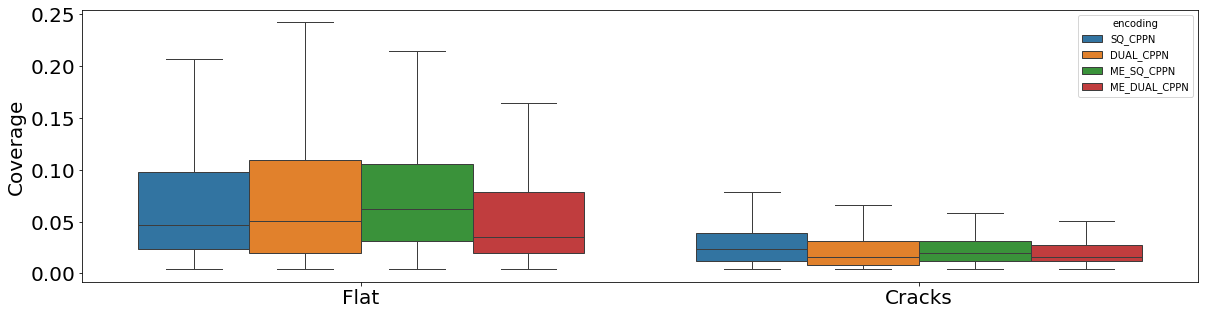

In [ ]:
fig = plt.gcf()
fig.set_size_inches(20,5)
ax = sns.boxplot(me_data,x="environment",hue="encoding",y="fitness",showfliers=False,palette={'SQ_CPPN':'C0','DUAL_CPPN':'C1','ME_SQ_CPPN':'C2','ME_DUAL_CPPN':'C3'})
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

/tmp/ipykernel_39650/2687299945.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8]),
 [Text(0, -0.1, '−0.1'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.20000000000000004, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5000000000000001, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8')])

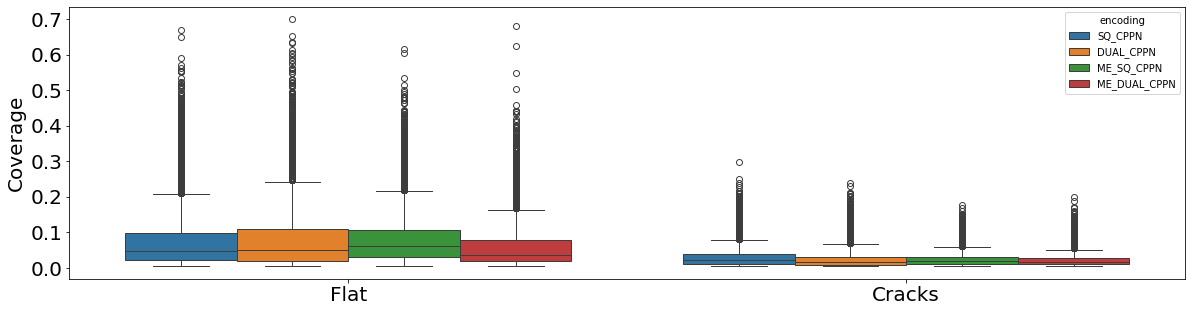

In [ ]:
fig = plt.gcf()
fig.set_size_inches(20,5)
ax = sns.boxplot(me_data,x="environment",hue="encoding",y="fitness")
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

## ME2HK SQ CPPN

In [ ]:
print(me_data)

        robot index   fitness     width     depth    height    voxels  wheels  \
0                32  0.023438  0.727273  0.909091  0.909091  0.353118     0.0   
1                24  0.015625  0.909091  0.909091  0.636364  0.279489     2.0   
2                58  0.070312  0.909091  0.545455  0.909091  0.324568     1.0   
3                31  0.078125  0.909091  0.818182  0.909091  0.181067     0.0   
4                39  0.011719  0.909091  0.909091  0.545455  0.124718     3.0   
...             ...       ...       ...       ...       ...       ...     ...   
306516        11871  0.003906  0.818182  0.909091  0.727273  0.202104     1.0   
306517        11894  0.007812  0.818182  0.909091  0.636364  0.201352     3.0   
306518        11933  0.011719  0.909091  0.727273  0.545455  0.188580     3.0   
306519        11887  0.015625  0.909091  0.909091  0.272727  0.049587     3.0   
306520        11862  0.035156  0.727273  0.727273  0.000000  0.022539     2.0   

        sensors  limbs  cas

In [ ]:
# Aggregate me_data by morphological features, computing mean fitness per group
me_data_aggr = me_data.groupby(['wheels', 'limbs', 'sensors', 'depth', 'width', 'height', 'encoding', 'environment']).agg({
    'fitness': 'mean',
    'robot index': 'count'
}).reset_index()

me_data_aggr.rename(columns={'robot index': 'count'}, inplace=True)

print(me_data_aggr[me_data_aggr["encoding"]=="ME_SQ_CPPN"]["limbs"].max(),me_data_aggr["wheels"].max(),me_data_aggr["sensors"].max())

8.0 8.0 8.0


In [612]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['me2im_sq_flat', 'me2im_sq_cracks'],# 'me2im_sq_obstacles', 'me2im_sq_rough', 'me2im_sq_holyrood' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks']#, 'Obstacles', 'Rough', 'Holyrood'],
}

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


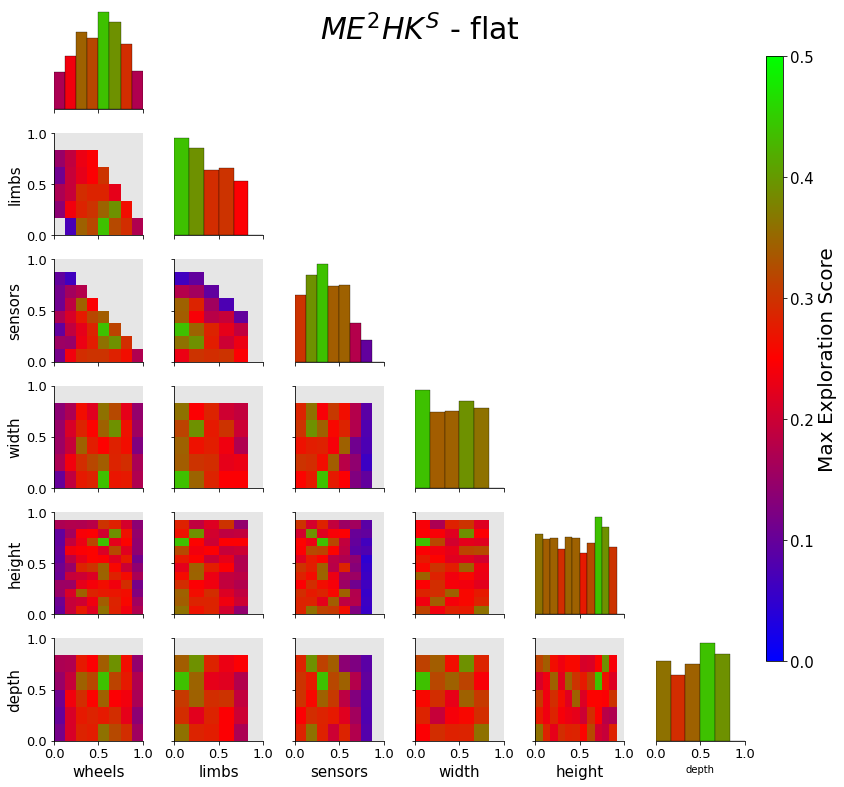

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


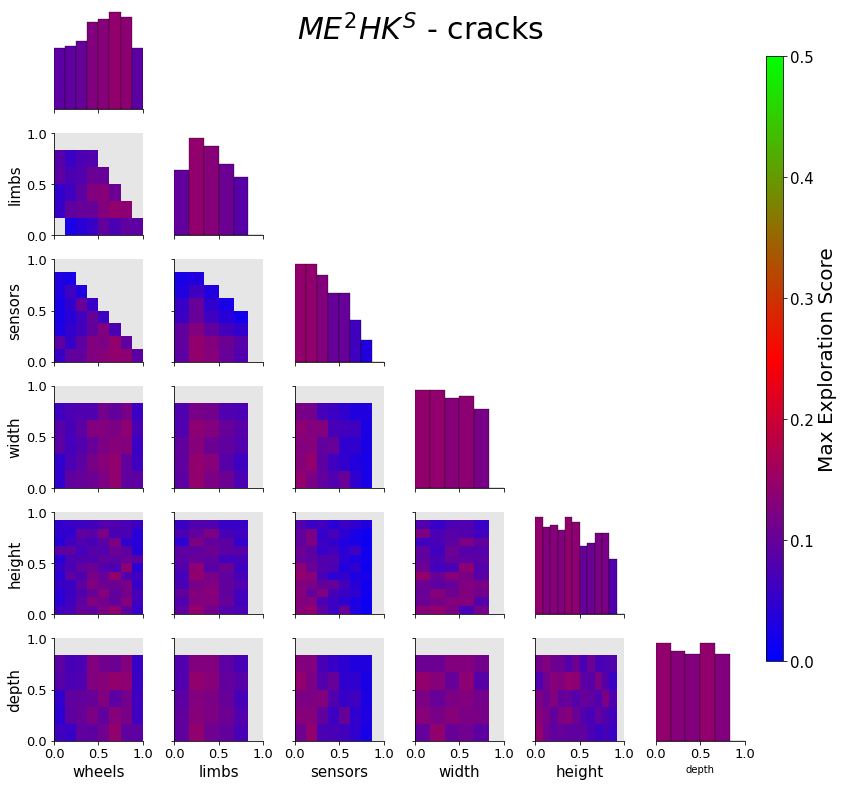

In [613]:
for env in experiments["name"]:
    plot_map_elites(me_data_aggr,env,"ME_SQ_CPPN","$ME^2HK^S$ - " + env)

## MEHK SQ CPPN

In [ ]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/"
experiments = {
    "directory" :  ['meim_sq_flat', 'meim_sq_cracks'],# 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks']#, 'Obstacles', 'Rough', 'Holyrood'],
}

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


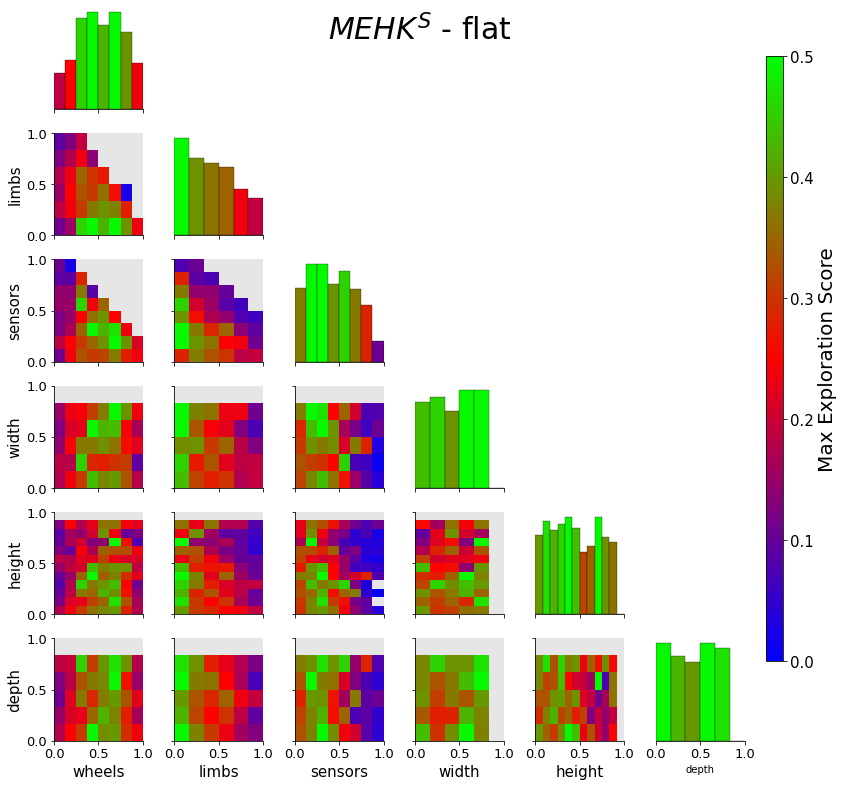

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


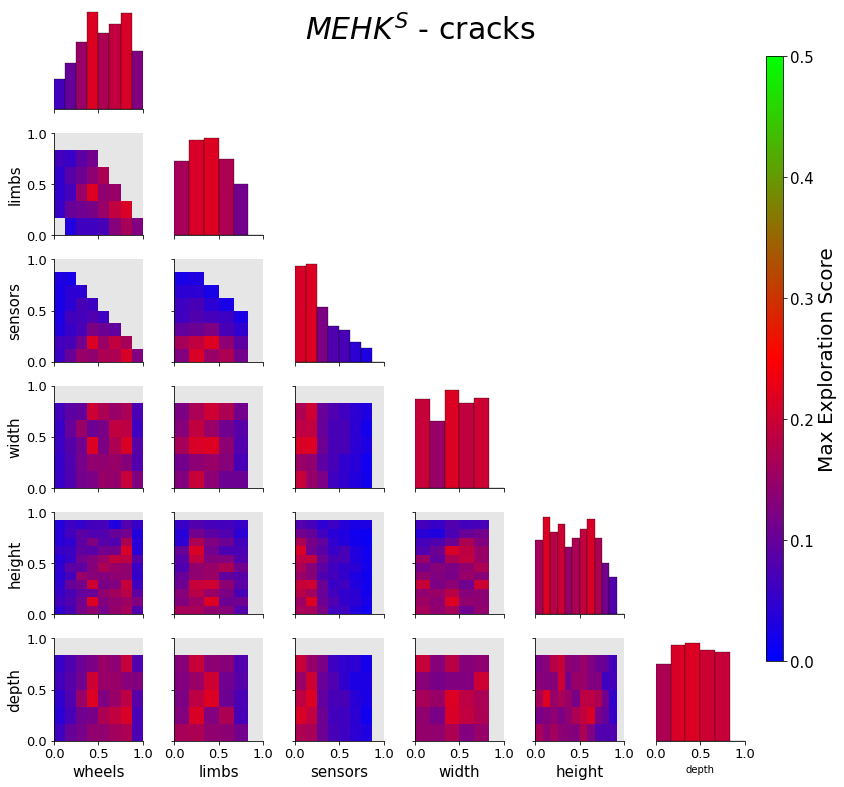

In [614]:
for env in experiments["name"]:
    plot_map_elites(me_data_aggr,env,"SQ_CPPN","$MEHK^S$ - " + env)

## MEHK DUAL CPPN

In [615]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['meim_cppn_flat', 'meim_cppn_cracks'],
    "name" :       ['flat', 'cracks'],
    "print_name" : ['Flat','Cracks'],
}

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


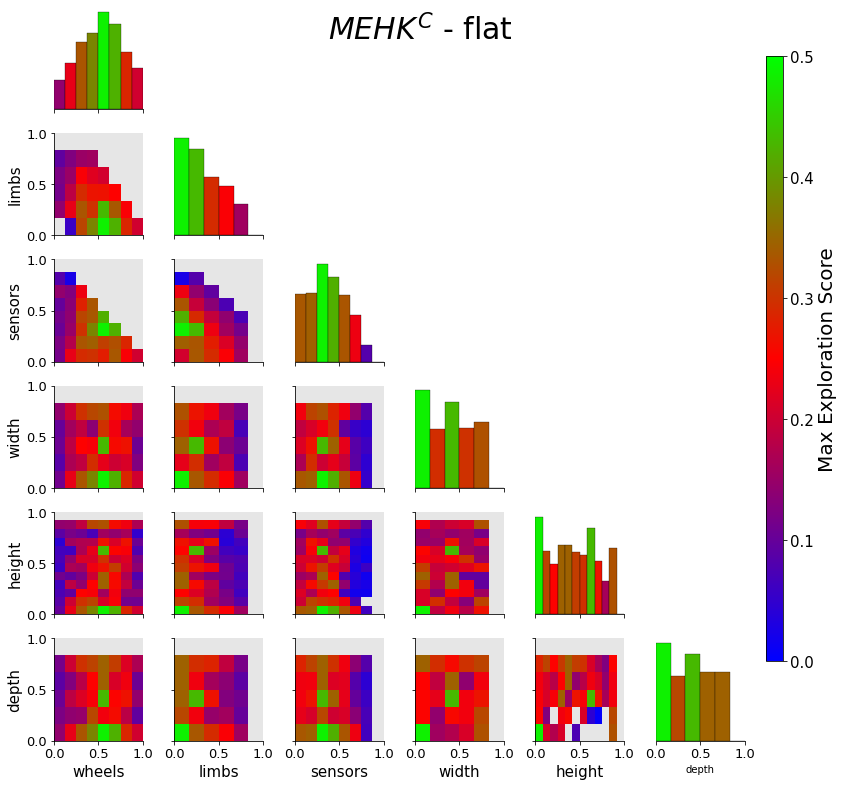

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


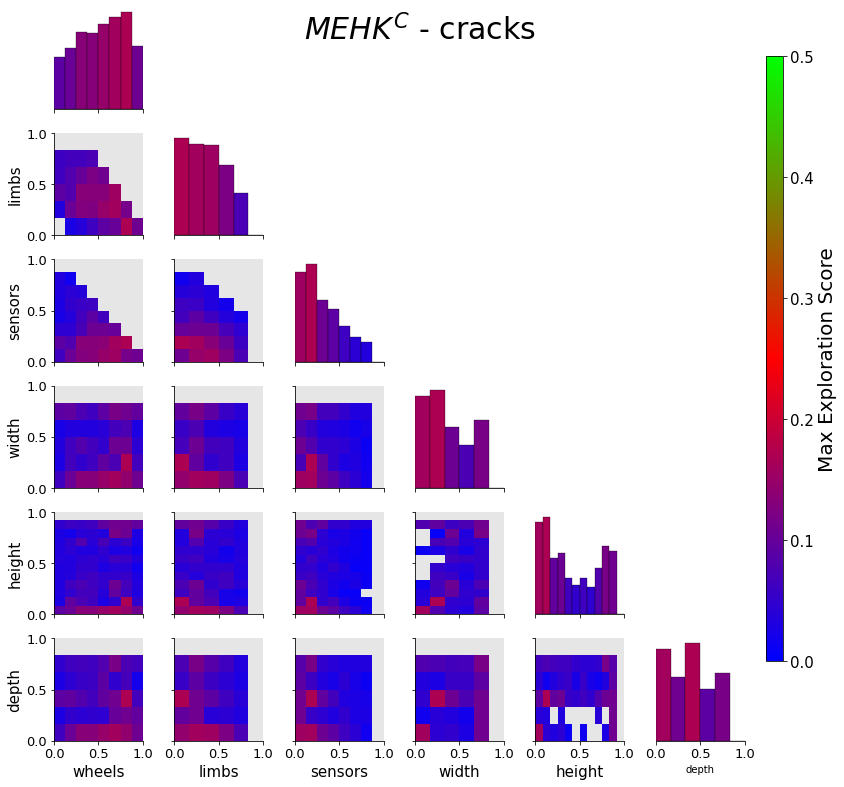

In [616]:
for env in experiments["name"]:
    plot_map_elites(me_data_aggr,env,"DUAL_CPPN","$MEHK^C$ - " + env)

## ME2HK DUAL CPPN

In [ ]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['me2im_cppn_flat', 'me2im_cppn_cracks'],# 'me2im_cppn_obstacles', 'me2im_cppn_rough', 'me2im_cppn_holyrood' ],
    "name" :       ['flat', 'cracks'],# 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Cracks']#, 'Obstacles', 'Rough', 'Holyrood'],
}

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


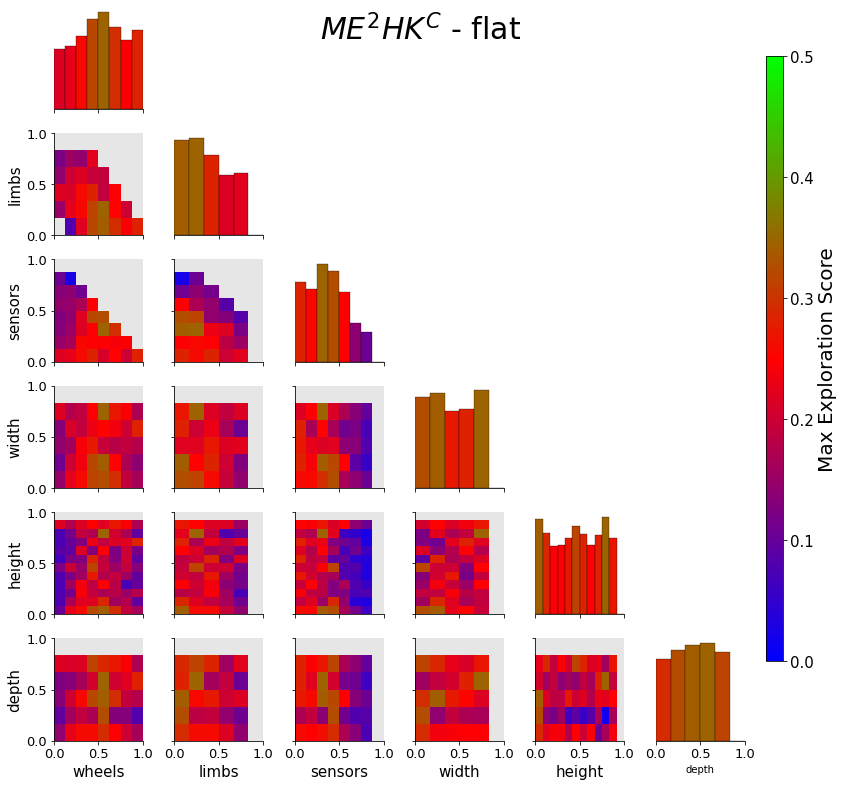

/tmp/ipykernel_39650/470239381.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])


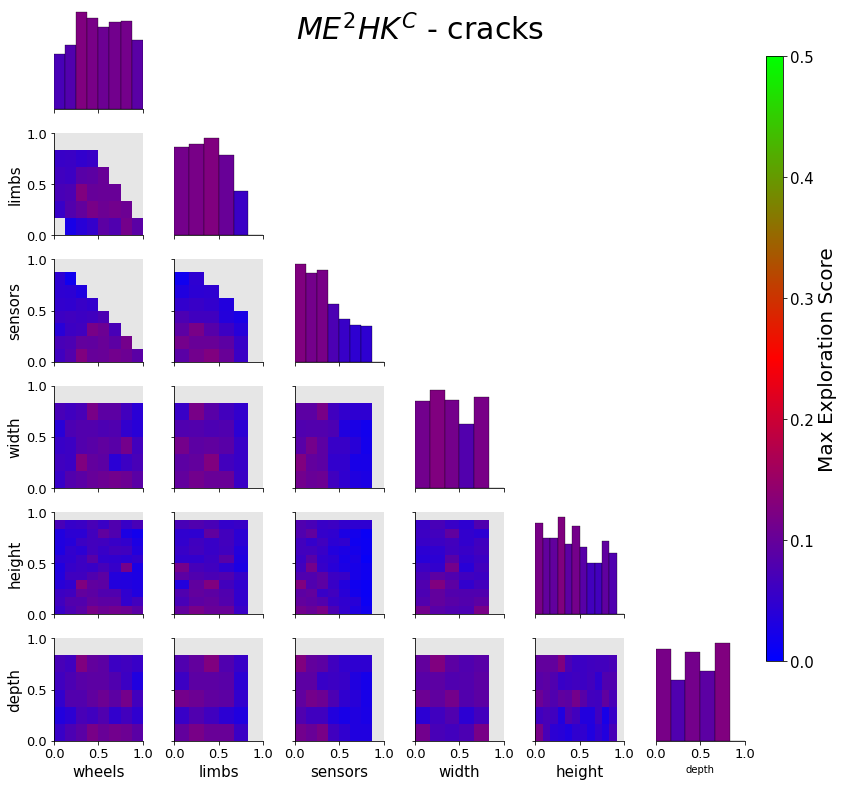

In [617]:
for env in experiments["name"]:
    plot_map_elites(me_data_aggr,env,"ME_DUAL_CPPN","$ME^2HK^C$ - " + env)

## Number of robots per numbers of components

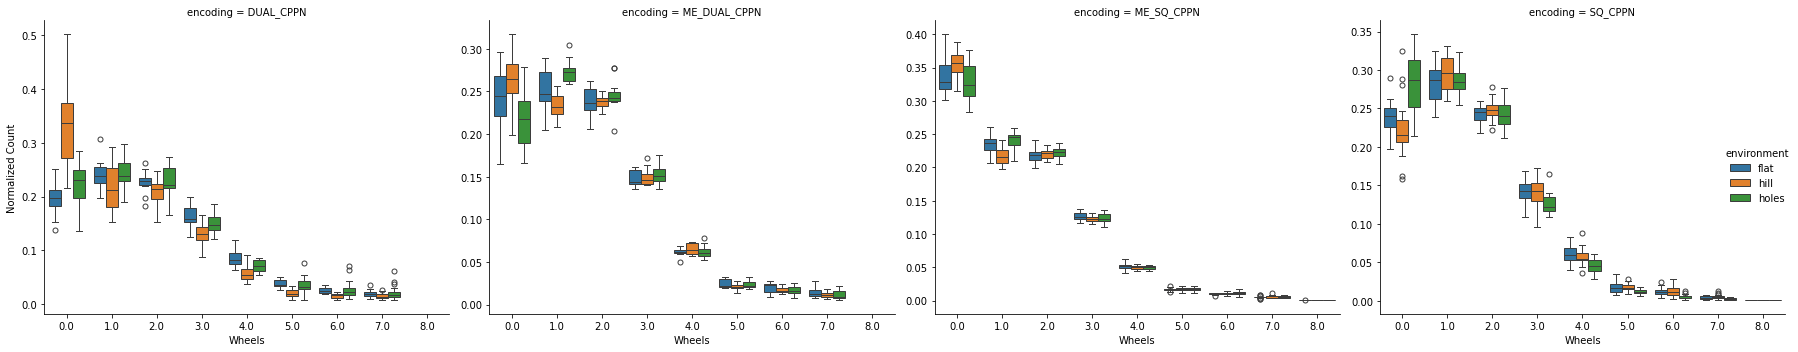

In [124]:
# Calculate normalized count of 'wheels' per environment, encoding, and replicate
group_cols = ['environment', 'encoding', 'replicate', 'wheels']
counts = me_data.groupby(group_cols).size().reset_index(name='count')

# Compute total count per environment, encoding, and replicate
total_counts = counts.groupby(['environment', 'encoding', 'replicate'])['count'].transform('sum')
counts['norm_count'] = counts['count'] / total_counts

# Plot using seaborn catplot
g = sns.catplot(
    data=counts,
    kind="box",
    col="encoding",
    x="wheels",
    y="norm_count",
    hue="environment",
    sharey=False,
    height=5,
    aspect=1.2
)
g.set_axis_labels("Wheels", "Normalized Count")
plt.tight_layout()
plt.show()

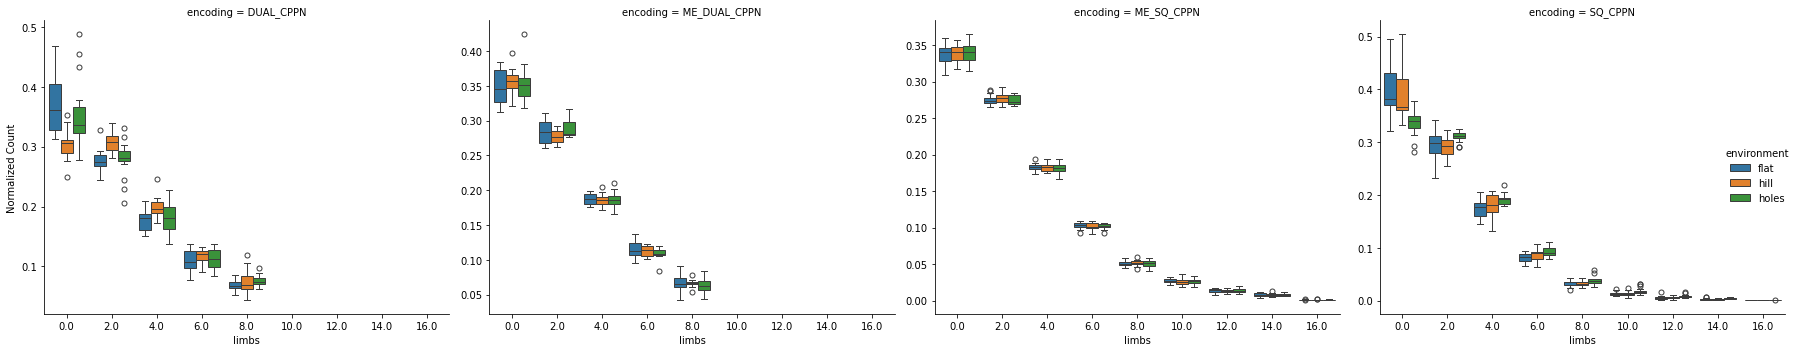

In [63]:
# Calculate normalized count of 'wheels' per environment, encoding, and replicate
group_cols = ['environment', 'encoding', 'replicate', 'limbs']
counts = me_data.groupby(group_cols).size().reset_index(name='count')

# Compute total count per environment, encoding, and replicate
total_counts = counts.groupby(['environment', 'encoding', 'replicate'])['count'].transform('sum')
counts['norm_count'] = counts['count'] / total_counts

# Plot using seaborn catplot
g = sns.catplot(
    data=counts,
    kind="box",
    col="encoding",
    x="limbs",
    y="norm_count",
    hue="environment",
    sharey=False,
    height=5,
    aspect=1.2
)
g.set_axis_labels("limbs", "Normalized Count")
plt.tight_layout()
plt.show()

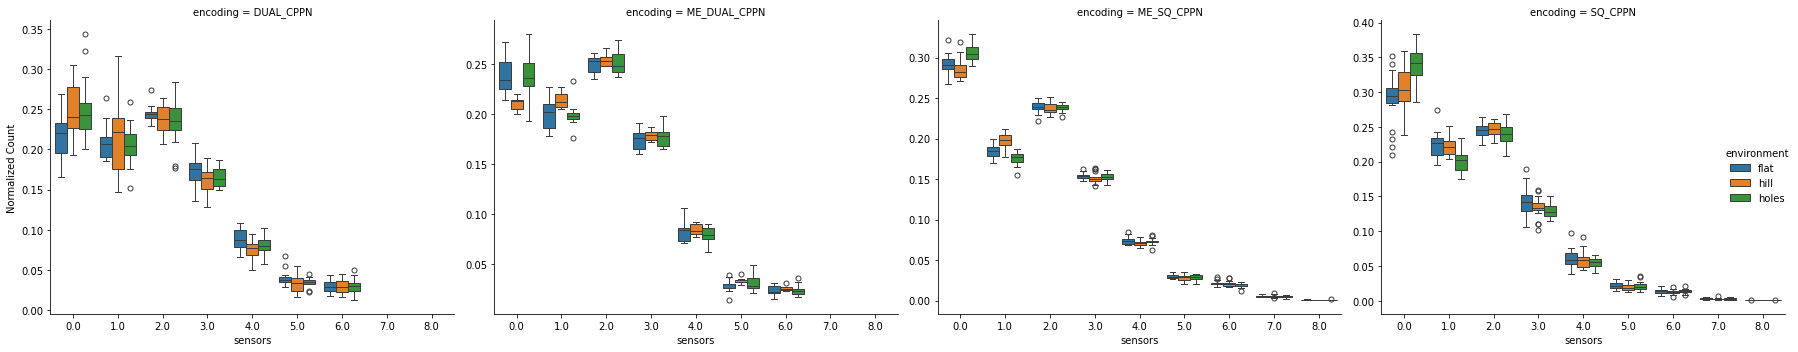

In [64]:
# Calculate normalized count of 'wheels' per environment, encoding, and replicate
group_cols = ['environment', 'encoding', 'replicate', 'sensors']
counts = me_data.groupby(group_cols).size().reset_index(name='count')

# Compute total count per environment, encoding, and replicate
total_counts = counts.groupby(['environment', 'encoding', 'replicate'])['count'].transform('sum')
counts['norm_count'] = counts['count'] / total_counts

# Plot using seaborn catplot
g = sns.catplot(
    data=counts,
    kind="box",
    col="encoding",
    x="sensors",
    y="norm_count",
    hue="environment",
    sharey=False,
    height=5,
    aspect=1.2
)
g.set_axis_labels("sensors", "Normalized Count")
plt.tight_layout()
plt.show()

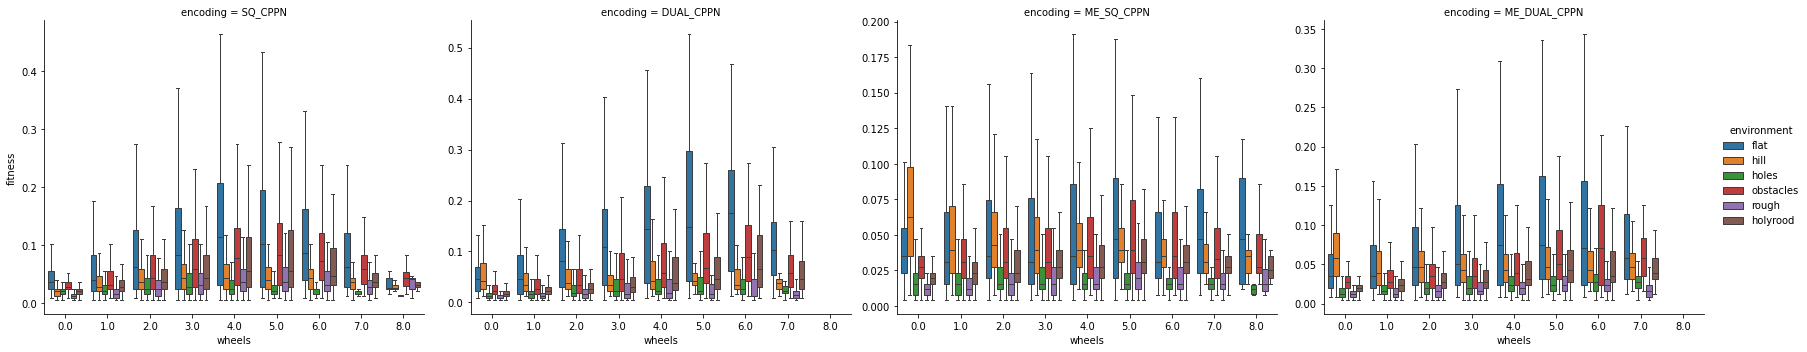

In [149]:
sns.catplot(data=me_data, x="wheels", y="fitness", hue="environment", col="encoding", kind="box", sharey=False, height=5, aspect=1.2,showfliers=False)

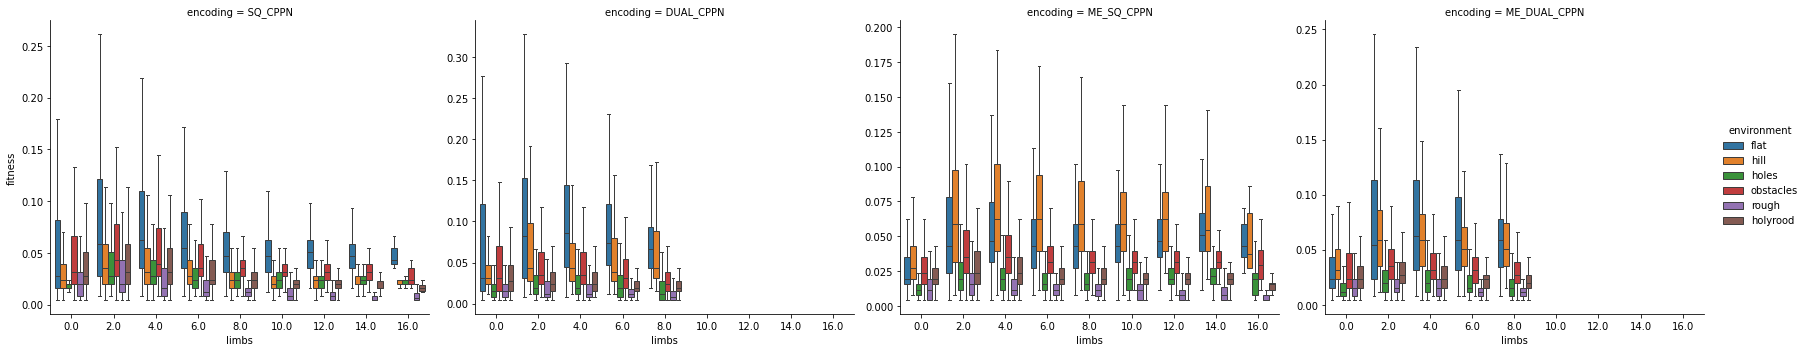

In [150]:
sns.catplot(data=me_data, x="limbs", y="fitness", hue="environment", col="encoding", kind="box", sharey=False, height=5, aspect=1.2,showfliers=False)

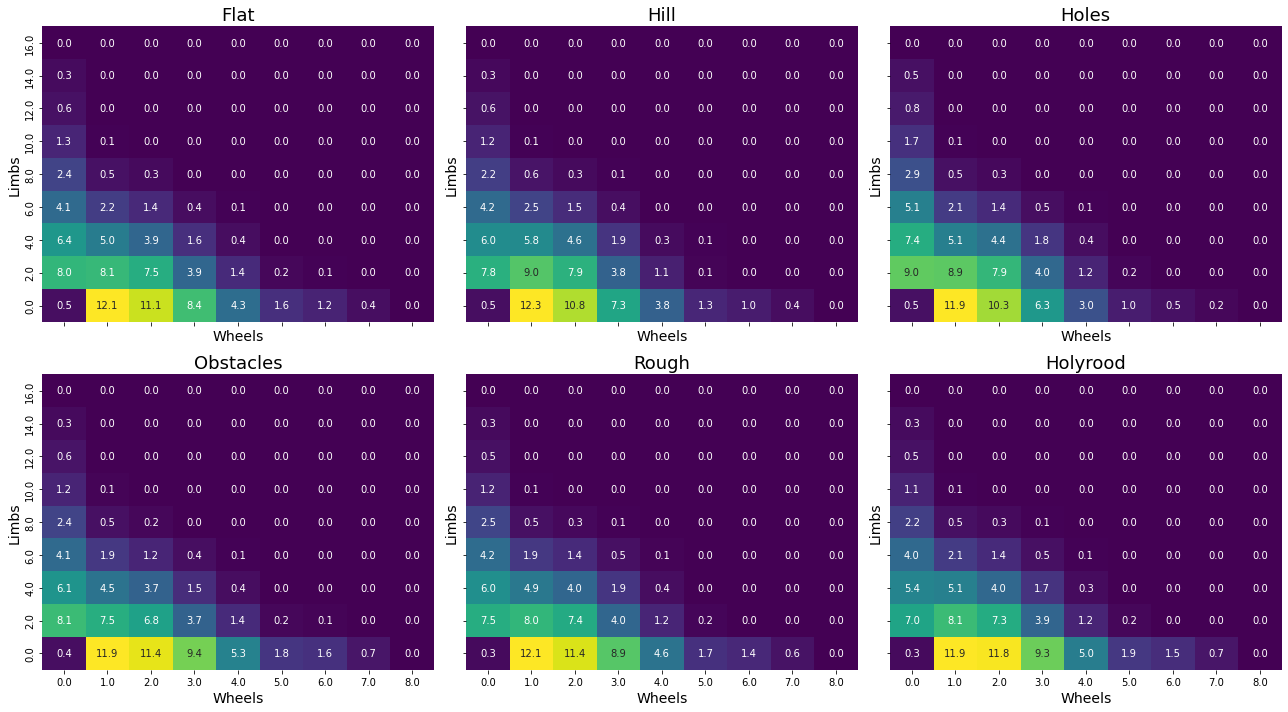

In [152]:
cpy_data = me_data[me_data['encoding'] == 'SQ_CPPN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

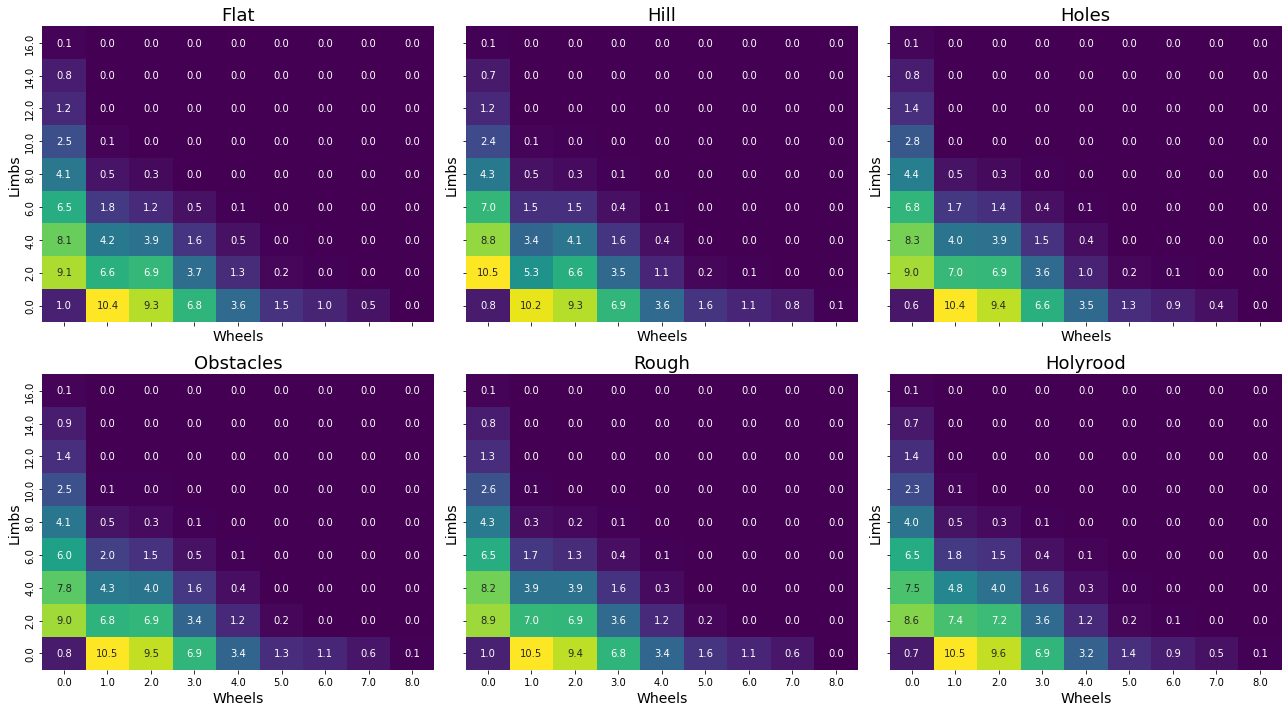

In [153]:
cpy_data = me_data[me_data['encoding'] == 'ME_SQ_CPPN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

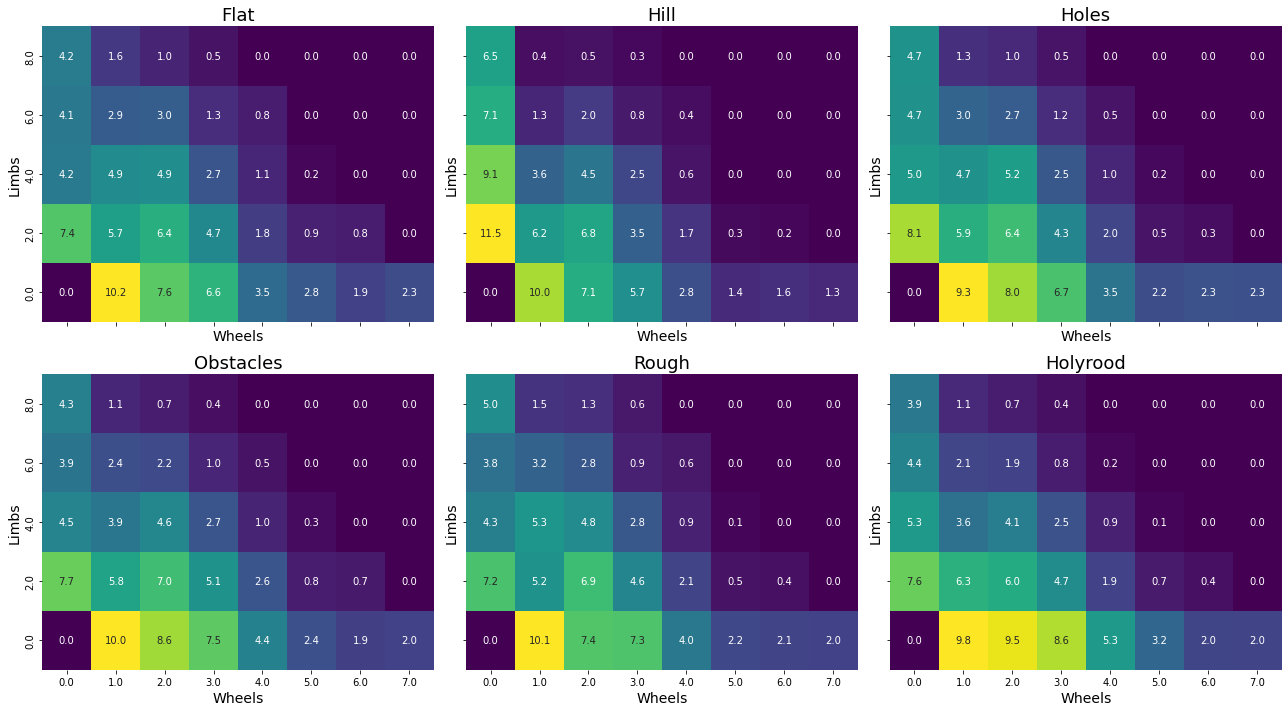

In [154]:
cpy_data = me_data[me_data['encoding'] == 'DUAL_CPPN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

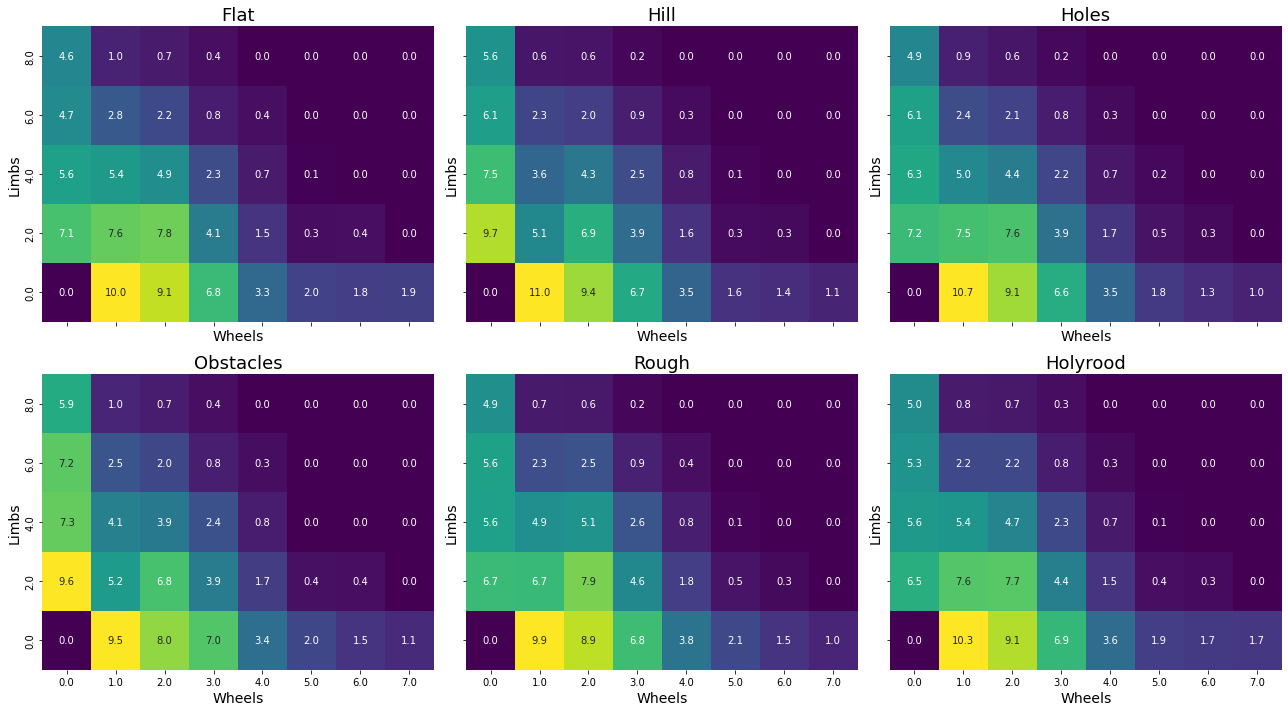

In [155]:
cpy_data = me_data[me_data['encoding'] == 'ME_DUAL_CPPN']
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = cpy_data[cpy_data["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(cpy_data['wheels'].unique())
    limbs_vals = sorted(cpy_data['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

## pacmap

In [114]:
import pacmap

/home/leni/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [255]:
import os
import joblib
from sklearn.preprocessing import StandardScaler

# Train a PaCMAP model per environment on the selected morphological dimensions

cols = ['wheels', 'limbs', 'sensors', 'width', 'height', 'depth']
out_dir = "pacmap_models"
os.makedirs(out_dir, exist_ok=True)

envs = me_data['environment'].unique()
models = {}
embeddings = []

me_data_archive = me_data[cols].dropna().copy()

# scale features
scaler = StandardScaler().fit(me_data_archive.values)
X = scaler.transform(me_data_archive.values)

# train PaCMAP
pm = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, num_iters=500, verbose=True)
embedding = pm.fit_transform(X)

# store model + scaler
model_path = os.path.join(out_dir, f"pacmap_{env}.joblib")
joblib.dump({'pacmap': pm, 'scaler': scaler, 'cols': cols}, model_path)

# attach embedding to the sampled dataframe (keep original indices)
emb_df = pd.DataFrame(embedding, index=me_data_archive.index, columns=[f'pacmap_x', f'pacmap_y'])
# emb_df['environment'] = env

models[env] = pm
print(f"Trained PaCMAP for {env}: samples={len(me_data_archive)}, saved to {model_path}")



X is normalized
PaCMAP(n_neighbors=32, n_MN=16, n_FP=64, distance=euclidean, lr=1.0, n_iters=(100, 100, 500), apply_pca=True, opt_method='adam', verbose=True, intermediate=False, seed=None)
Finding pairs
Found nearest neighbor
Calculated sigma
Found scaled dist
Pairs sampled successfully.
((8717376, 2), (4358688, 2), (17434752, 2))
Initial Loss: 10242891.0
Iteration:   10, Loss: 6992125.000000
Iteration:   20, Loss: 6447159.000000
Iteration:   30, Loss: 6083856.000000
Iteration:   40, Loss: 5764378.000000
Iteration:   50, Loss: 5459694.000000
Iteration:   60, Loss: 5145368.500000
Iteration:   70, Loss: 4775483.500000
Iteration:   80, Loss: 4305130.000000
Iteration:   90, Loss: 3696610.750000
Iteration:  100, Loss: 2686579.750000
Iteration:  110, Loss: 3106688.250000
Iteration:  120, Loss: 2988319.250000
Iteration:  130, Loss: 2944614.000000
Iteration:  140, Loss: 2927161.500000
Iteration:  150, Loss: 2919787.000000
Iteration:  160, Loss: 2915734.500000
Iteration:  170, Loss: 2912926.50

In [256]:
# combine embeddings (for sampled rows)
pacmap_embeddings = pd.concat([emb_df]).sort_index()
# merge embeddings back into me_data (NaN for rows not sampled)
me_data_pacmap = me_data.join(pacmap_embeddings[['pacmap_x','pacmap_y']], how='left')
# save embeddings to disk
pacmap_embeddings.to_csv(os.path.join(out_dir, "pacmap_embeddings_sampled.csv"))

<Figure size 1440x1440 with 0 Axes>

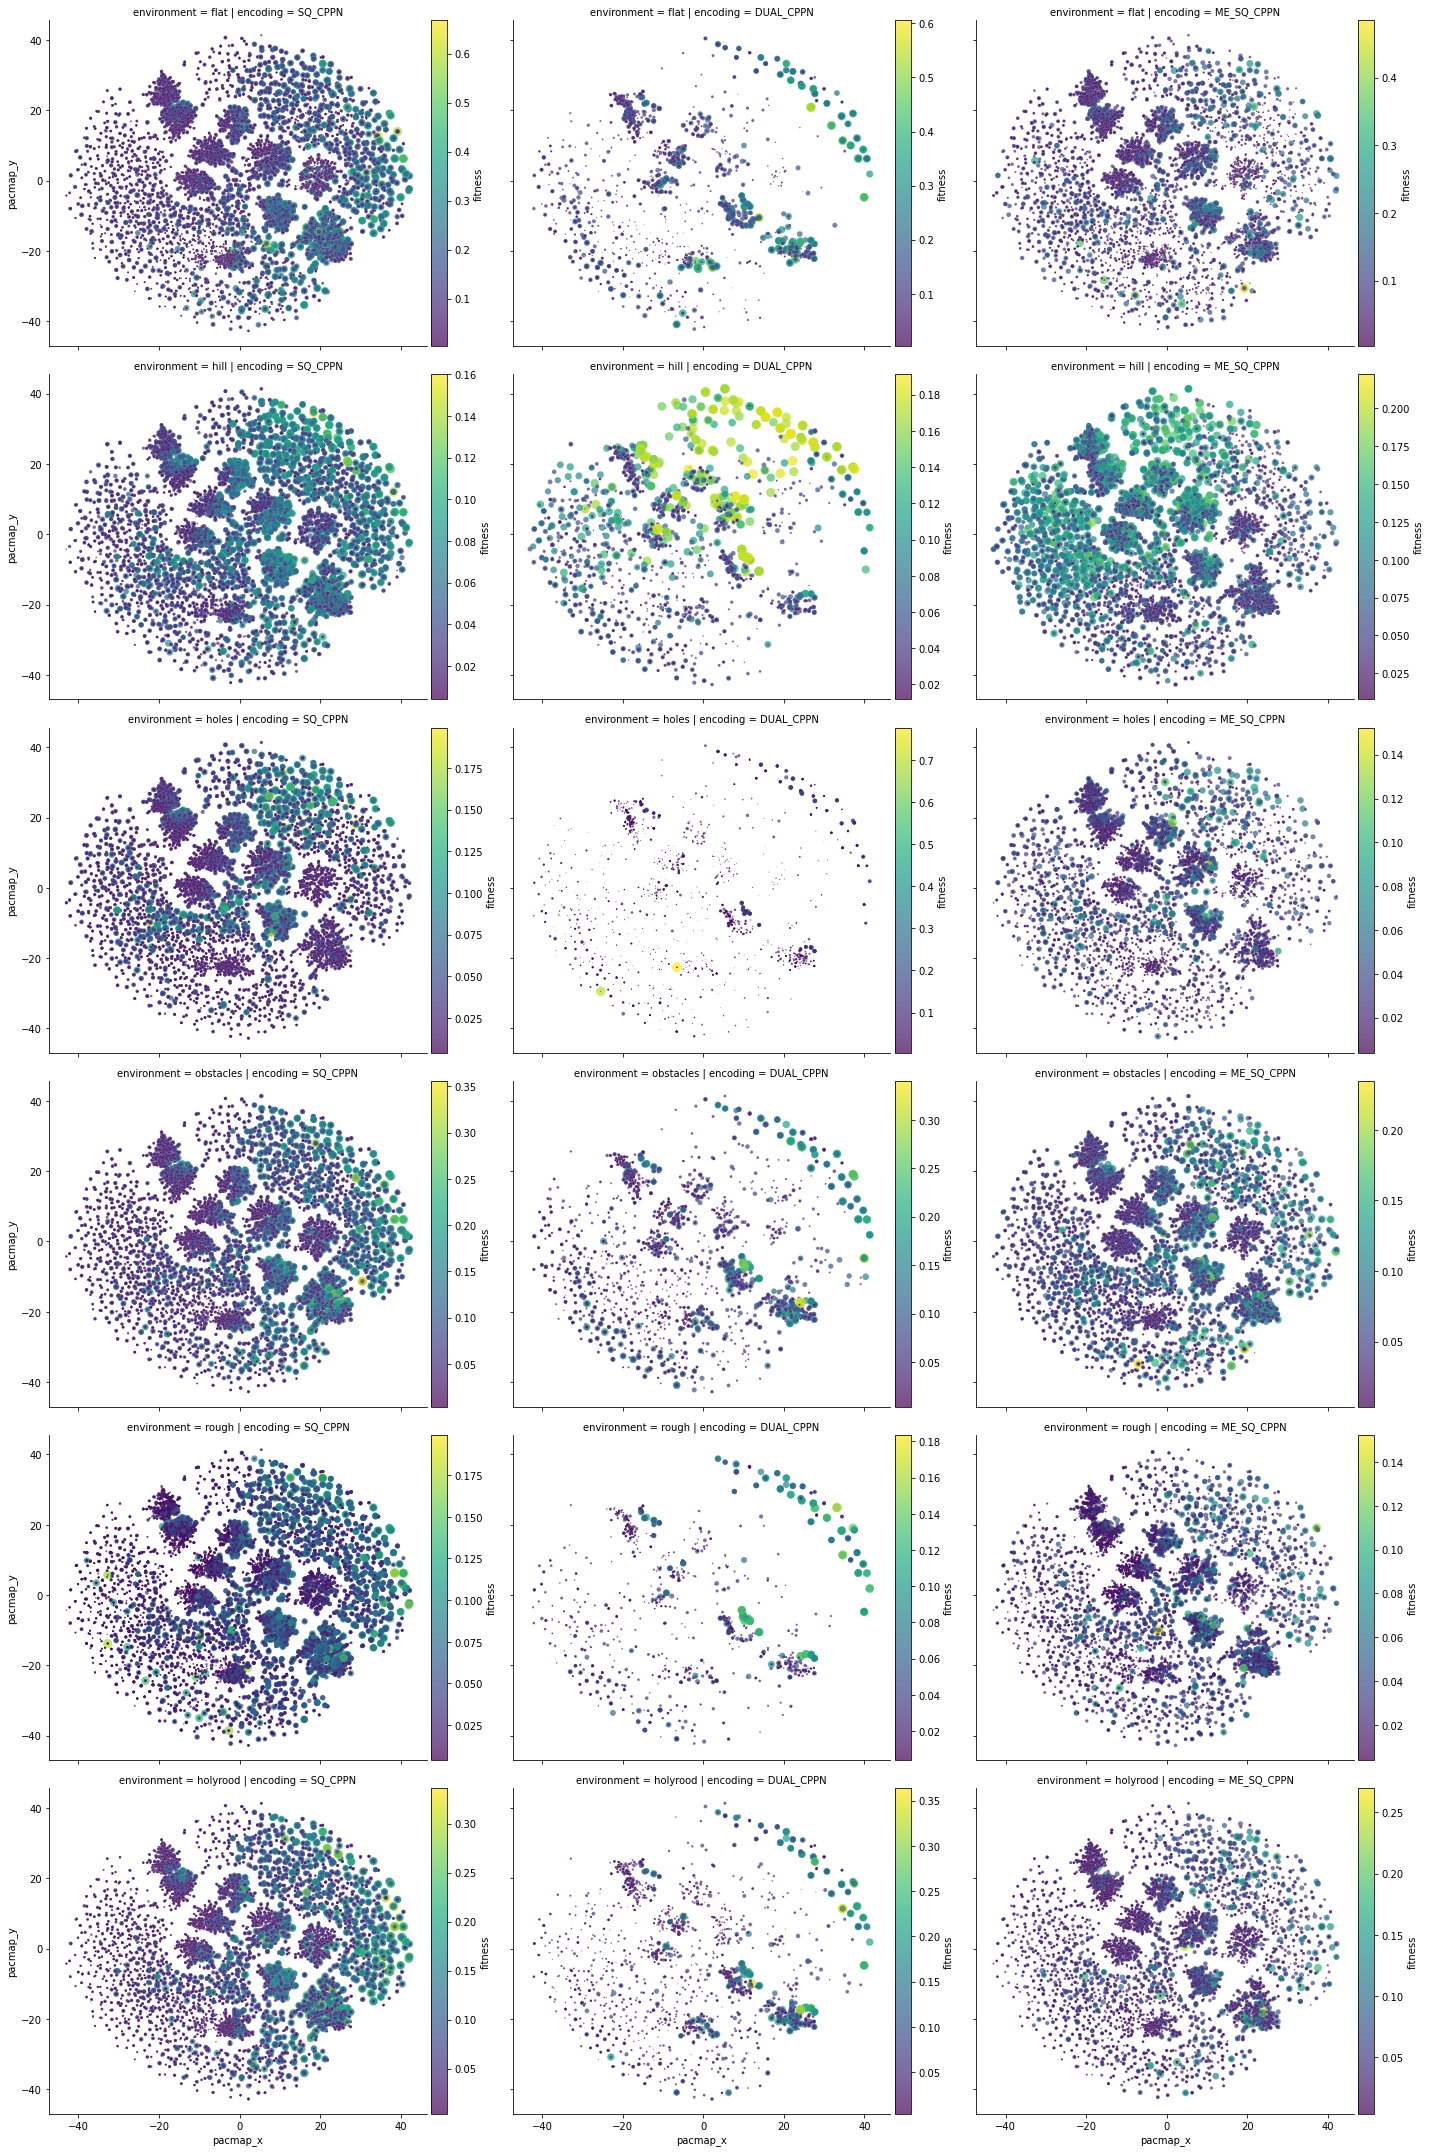

In [268]:
import matplotlib as mpl

fig = plt.gcf()
fig.set_size_inches(20,20)
g = sns.relplot(data=me_data_pacmap,
                x="pacmap_x", y="pacmap_y",
                row="environment", col="encoding",
                size="fitness", hue="fitness",
                sizes=(0,100), alpha=0.7,
                palette="viridis",
                legend=False)  # disable the global legend so we can add per-facet colorbars

# get row/col names from the FacetGrid if available, else fallback to unique values
row_names = getattr(g, "row_names", list(me_data_pacmap["environment"].unique()))
col_names = getattr(g, "col_names", list(me_data_pacmap["encoding"].unique()))

for i, env in enumerate(row_names):
    for j, enc in enumerate(col_names):
        ax = g.axes[i, j]
        df_sub = me_data_pacmap[(me_data_pacmap["environment"] == env) & (me_data_pacmap["encoding"] == enc)]
        if df_sub.empty:
            continue

        vmin = float(df_sub["fitness"].min())
        vmax = float(df_sub["fitness"].max())
        # avoid degenerate normalization
        if vmax == vmin:
            norm = mpl.colors.Normalize(vmin=vmin - 0.5, vmax=vmax + 0.5)
        else:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        # Try to find the scatter PathCollection(s) on this axis and re-normalize them per-facet
        collections = ax.collections
        if not collections:
            continue

        # Prefer collections that match the number of points plotted for this facet
        target_cols = []
        for coll in collections:
            offs = coll.get_offsets()
            if offs is None:
                continue
            if offs.shape[0] == len(df_sub):
                target_cols.append(coll)
        if not target_cols:
            target_cols = collections  # fallback
                # hide points with fitness lower than (max-min)/2

        # map fitness -> size range used in the original relplot
        size_min, size_max = 0.0, 100.0
        for coll in target_cols:
            offs = coll.get_offsets()
            # set array values for color if lengths match, else try to preserve existing array but apply new norm
            if offs is not None and offs.shape[0] == len(df_sub):
                fitness_vals = df_sub["fitness"].values
                coll.set_array(fitness_vals)
                # compute per-facet sizes (handle degenerate case)
                if vmax == vmin:
                    sizes = np.full_like(fitness_vals, (size_min + size_max) / 2.0)
                else:
                    sizes = (fitness_vals - vmin) / (vmax - vmin) * (size_max - size_min) + size_min
                coll.set_sizes(sizes)
            else:
                arr = coll.get_array()
                if arr is None:
                    arr = np.full(offs.shape[0] if offs is not None else 1, vmin)
                coll.set_array(arr)
                # try to adjust existing sizes array if present
                try:
                    existing_sizes = coll.get_sizes()
                    if existing_sizes is None or len(existing_sizes) != (offs.shape[0] if offs is not None else 1):
                        coll.set_sizes(np.full(offs.shape[0] if offs is not None else 1, (size_min + size_max) / 2.0))
                except Exception:
                    pass

            coll.set_cmap("viridis")
            coll.set_norm(norm)

        # add a small colorbar for this facet
        try:
            g.fig.colorbar(target_cols[-1], ax=ax, label="fitness", pad=0.01)
        except Exception:
            pass

g.fig.set_size_inches(20, 30)
plt.tight_layout()
plt.show()